# Optimización y selección del modelo final

Notebook del issue 21. Parte de los modelos baseline del ticket 10 (semana 6) y busca mejorarlos de forma ordenada, dejando cada idea registrada en MLflow para poder compararlas.

Preguntas que responde:

1. ¿Qué variables ayudan más a predecir `neurodev_alteration`? El ranking sirve para decidir qué pedir en el formulario de la API.
2. ¿Mejoran los modelos con ajuste de hiperparámetros, pesos de clase, selección de variables, nuevas arquitecturas o sobremuestreo?
3. ¿Cuál es el modelo definitivo y qué dice sobre los pacientes (odds ratios)?
4. ¿Cuánto pesan los valores por defecto de la calculadora en el puntaje que ve el usuario?

**Criterio de selección.** Recall como criterio principal, condicionado a ROC-AUC. Como los falsos positivos y los falsos negativos son costosos, Recall solo no alcanza: un clasificador que marque a todos como anormales tiene Recall 1.0. Por eso se incluye siempre ese clasificador trivial como referencia, y el criterio definitivo (sección 4) mide el Recall alcanzable con una precisión mínima.

**Protocolo.** Validación cruzada estratificada repetida (5 folds, 3 repeticiones) sobre las 89 filas. El split fijo 71/18 de la semana 6 se conserva solo para comparar con esos resultados. Los modelos con búsqueda de hiperparámetros se evalúan con validación cruzada anidada, para que el ajuste no infle la métrica.

In [1]:
import os
import sys
import warnings
from pathlib import Path

sys.path.append("..")

import joblib
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from dotenv import load_dotenv
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline
from joblib import Parallel, delayed
from mlflow.tracking import MlflowClient
from scipy.stats import false_discovery_control, fisher_exact, mannwhitneyu
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.feature_selection import SelectFromModel, VarianceThreshold
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    RepeatedStratifiedKFold,
    StratifiedKFold,
    StratifiedShuffleSplit,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from xgboost import XGBClassifier

from src.models.train import (
    CONTINUOUS_VARS,
    RANDOM_STATE,
    build_models,
    build_preprocessor,
    load_dataset,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

ROOT = Path("..").resolve()
load_dotenv(ROOT / ".env")
TRACKING_URI = os.environ.get("MLFLOW_TRACKING_URI", "http://localhost:5000")
EXPERIMENT = os.environ.get("EXPERIMENT_NAME", "optimizacion_modelo_final")
REFERENCE_EXPERIMENT = "preterm_infant_prediction"

try:
    requests.get(f"{TRACKING_URI}/health", timeout=5).raise_for_status()
except requests.RequestException as exc:
    raise RuntimeError(
        f"No hay servidor MLflow en {TRACKING_URI}. Levantarlo con "
        "`uv run poe mlflow-ui` o apuntar MLFLOW_TRACKING_URI al servidor "
        "compartido."
    ) from exc

mlflow.set_tracking_uri(TRACKING_URI)
if MlflowClient().get_experiment_by_name(EXPERIMENT) is None:
    # Con el proxy de artefactos del servidor, los archivos (joblib y figuras)
    # viajan por HTTP. Sin esto, un servidor con ruta local por defecto hace
    # que el cliente los escriba en su propio disco.
    MlflowClient().create_experiment(
        EXPERIMENT, artifact_location=f"mlflow-artifacts:/{EXPERIMENT}"
    )
mlflow.set_experiment(EXPERIMENT)
print("Servidor MLflow:", TRACKING_URI)
print("Experimento:", EXPERIMENT)

C:\Users\USUARIO\Documents\ARCHIVOS\Documents\Maestria\MLOps\Microproyecto\Microproyecto\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Servidor MLflow: http://44.215.228.113:5000
Experimento: optimizacion_modelo_final


In [2]:
X, y = load_dataset()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
prevalence = float(y.mean())

# Las 5 variables que hoy pide el formulario del dashboard y la API.
FORM_FIELDS = ["DM", "preeclampsia", "PregnancyAge", "BirthWeight", "apgar5"]


def make_pipeline(model):
    return Pipeline([("preprocess", build_preprocessor(X)), ("model", model)])


print(f"Filas: {len(X)}, predictores: {X.shape[1]}")
print(f"Prevalencia de la clase anormal: {prevalence:.3f}")
print(f"Split fijo de la semana 6: train {len(X_train)}, test {len(X_test)}")

Filas: 89, predictores: 37
Prevalencia de la clase anormal: 0.528
Split fijo de la semana 6: train 71, test 18


## 1. Estudio de variables

Objetivo: entregar al equipo de API y dashboard un ranking de qué variables conviene pedir en el formulario. Se combinan cuatro criterios distintos, porque ninguno es confiable por sí solo con 89 filas:

* **Poder univariado.** AUC de cada variable contra el target, con su valor p (Fisher para binarias, Mann Whitney para continuas) y corrección por comparaciones múltiples.
* **Estabilidad de la selección con L1.** Se repite una regresión logística con penalización L1 sobre 200 submuestras y se mide en qué fracción de ellas la variable queda seleccionada. Con variables correlacionadas, una sola corrida de L1 elige una al azar, por eso se mide la estabilidad.
* **Importancia por permutación** en validación cruzada, para un modelo lineal y uno de árboles.

Este estudio es exploratorio. Usa todas las filas para ordenar variables, no para estimar desempeño, así que no reemplaza la validación de la sección 3.

In [3]:
binary_cols = [c for c in X.columns if set(X[c].dropna().unique()) <= {0, 1}]
continuous_cols = [c for c in X.columns if c not in binary_cols]

rows = []
for col in X.columns:
    mask = X[col].notna()
    xs, ys = X.loc[mask, col], y[mask]
    is_binary = col in binary_cols
    row = {"variable": col, "tipo": "binaria" if is_binary else "continua"}
    row["positivos"] = int(xs.sum()) if is_binary else np.nan
    if xs.nunique() < 2:
        row["auc_univariado"], row["p_valor"] = np.nan, np.nan
    else:
        row["auc_univariado"] = roc_auc_score(ys, xs)
        if is_binary:
            tabla = pd.crosstab(xs, ys).reindex(
                index=[0.0, 1.0], columns=[0, 1], fill_value=0
            )
            row["p_valor"] = fisher_exact(tabla.to_numpy())[1]
        else:
            row["p_valor"] = mannwhitneyu(xs[ys == 1], xs[ys == 0]).pvalue
    rows.append(row)

univariate = pd.DataFrame(rows).set_index("variable")
valid = univariate["p_valor"].notna()
univariate.loc[valid, "p_ajustado_fdr"] = false_discovery_control(
    univariate.loc[valid, "p_valor"].to_numpy()
)
auc = univariate["auc_univariado"]
univariate["poder_univariado"] = (auc - 0.5).abs() * 2
univariate["direccion"] = np.select(
    [auc > 0.5, auc < 0.5],
    ["sube el riesgo", "baja el riesgo"],
    default="sin variación",
)

cols = ["tipo", "positivos", "auc_univariado", "p_valor", "p_ajustado_fdr"]
univariate.sort_values("poder_univariado", ascending=False)[[*cols, "direccion"]].round(
    3
).head(15)

,tipo,positivos,auc_univariado,p_valor,p_ajustado_fdr,direccion
variable,,,,,,
BirthWeight,continua,NaN,0.257,0.000,0.003,baja el riesgo
duration.hopitalization,continua,NaN,0.731,0.000,0.003,sube el riesgo
duration.O2,continua,NaN,0.689,0.002,0.016,sube el riesgo
RoundHeadAtBirth,continua,NaN,0.319,0.003,0.023,baja el riesgo
PregnancyAge,continua,NaN,0.329,0.004,0.023,baja el riesgo
IUGR,binaria,30.0,0.639,0.007,0.032,sube el riesgo
BPD,binaria,14.0,0.626,0.001,0.012,sube el riesgo
SepsisnegativeCulture,binaria,18.0,0.624,0.004,0.023,sube el riesgo
intervencion_respiratoria_agresiva,binaria,24.0,0.620,0.016,0.064,sube el riesgo


Pares de variables con correlación de Spearman mayor a 0.6: 14
                            variable_a                             variable_b   rho
                         laborType_NVD                           laborType_cs -1.00
                   ehya.badve.tavallod type.of.ressucitation_no_resuscitation -0.97
                                apgar1                                 apgar5  0.90
                                sepsis                                    B.C  0.84
                           BirthWeight                       RoundHeadAtBirth  0.83
                   ehya.badve.tavallod              type.of.ressucitation_ppv  0.80
type.of.ressucitation_no_resuscitation              type.of.ressucitation_ppv -0.78
             notaggressive.ventilation                            duration.O2  0.75
                           duration.O2     intervencion_respiratoria_agresiva  0.74
               duration.hopitalization                            duration.O2  0.67
             

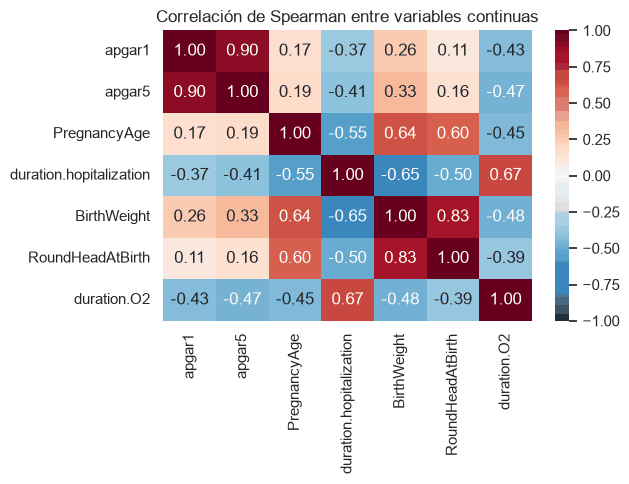

In [4]:
corr = X.corr(method="spearman")
upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
pairs = upper.stack().rename("rho").reset_index()
pairs.columns = ["variable_a", "variable_b", "rho"]
pairs = pairs[pairs["rho"].abs() >= 0.6]
pairs = pairs.sort_values("rho", key=lambda s: s.abs(), ascending=False)
print(f"Pares de variables con correlación de Spearman mayor a 0.6: {len(pairs)}")
print(pairs.round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(
    X[continuous_cols].corr(method="spearman"),
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    ax=ax,
)
ax.set_title("Correlación de Spearman entre variables continuas")
plt.tight_layout()
plt.show()

In [5]:
preprocessor = build_preprocessor(X)
Xt = preprocessor.fit_transform(X)
feature_names = [n.split("__", 1)[1] for n in preprocessor.get_feature_names_out()]

C_GRID = [0.05, 0.1, 0.2, 0.5]
N_SUBSAMPLES = 200
counts = np.zeros((len(C_GRID), len(feature_names)))
splitter = StratifiedShuffleSplit(
    n_splits=N_SUBSAMPLES, train_size=0.7, random_state=RANDOM_STATE
)
for idx, _ in splitter.split(Xt, y):
    for i, c in enumerate(C_GRID):
        model = LogisticRegression(l1_ratio=1, solver="liblinear", C=c, max_iter=1000)
        model.fit(Xt[idx], y.iloc[idx])
        counts[i] += model.coef_[0] != 0

stability = pd.DataFrame(
    counts.T / N_SUBSAMPLES,
    index=feature_names,
    columns=[f"C={c}" for c in C_GRID],
)
stability["estabilidad_l1"] = stability.max(axis=1)
stability.sort_values("estabilidad_l1", ascending=False).round(2).head(12)

,C=0.05,C=0.1,C=0.2,C=0.5,estabilidad_l1
duration.O2,0.16,0.98,1.00,0.98,1.00
BirthWeight,0.00,0.06,0.95,0.98,0.98
duration.hopitalization,0.00,0.00,0.31,0.78,0.78
icter,0.00,0.00,0.00,0.41,0.41
laborType_cs,0.00,0.00,0.00,0.40,0.40
SepsisnegativeCulture,0.00,0.00,0.00,0.30,0.30
apgar5,0.00,0.00,0.01,0.28,0.28
apgar1,0.00,0.00,0.08,0.26,0.26
IUGR,0.00,0.00,0.00,0.18,0.18
RoundHeadAtBirth,0.00,0.00,0.00,0.14,0.14


In [6]:
def cv_permutation_importance(model, n_repeats=5):
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=RANDOM_STATE)
    importances = []
    for tr, te in cv.split(X, y):
        fitted = clone(model).fit(X.iloc[tr], y.iloc[tr])
        result = permutation_importance(
            fitted,
            X.iloc[te],
            y.iloc[te],
            scoring="roc_auc",
            n_repeats=n_repeats,
            random_state=RANDOM_STATE,
        )
        importances.append(result.importances_mean)
    return pd.Series(np.mean(importances, axis=0), index=X.columns)


perm_lr = cv_permutation_importance(
    make_pipeline(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
)
perm_rf = cv_permutation_importance(
    make_pipeline(RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE))
)
pd.DataFrame({"permutacion_lr": perm_lr, "permutacion_rf": perm_rf}).sort_values(
    "permutacion_lr", ascending=False
).round(3).head(10)

,permutacion_lr,permutacion_rf
BirthWeight,0.045,0.083
duration.hopitalization,0.039,0.036
duration.O2,0.032,0.008
SepsisnegativeCulture,0.024,0.007
IUGR,0.016,-0.008
apgar5,0.016,-0.009
sepsis,0.011,0.005
PROM,0.010,0.002
BPD,0.009,0.005
type.of.ressucitation_ppv,0.005,0.003


Variables constantes, sin información en esta muestra: ['meningitis']


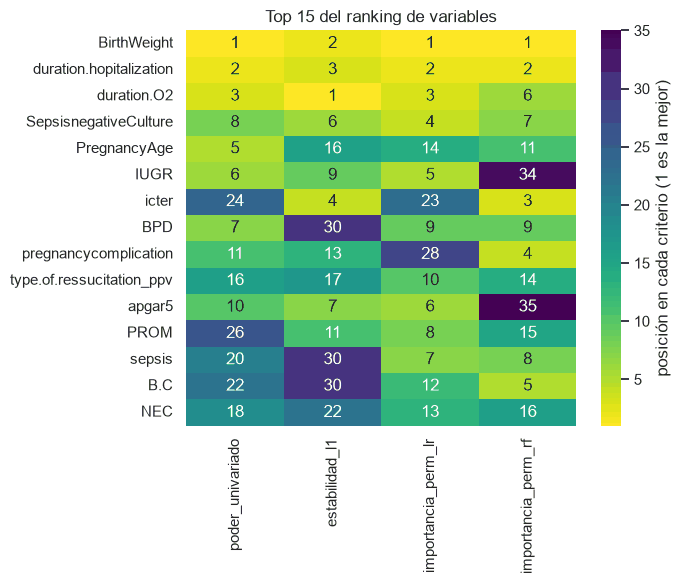

Ranking exportado a docs\ranking_variables.csv

Posición de las 5 variables del formulario actual:


,posicion,rango_promedio,soporte_bajo
DM,28,23.6,False
preeclampsia,29,24.0,False
PregnancyAge,5,11.4,False
BirthWeight,1,1.2,False
apgar5,11,14.5,False


In [7]:
constant = [c for c in X.columns if X[c].nunique() < 2]
print("Variables constantes, sin información en esta muestra:", constant)

ranking = pd.DataFrame(
    {
        "poder_univariado": univariate["poder_univariado"],
        "estabilidad_l1": stability["estabilidad_l1"].reindex(X.columns),
        "importancia_perm_lr": perm_lr,
        "importancia_perm_rf": perm_rf,
    }
).drop(index=constant)
ranking["tipo"] = univariate["tipo"]
ranking["positivos"] = univariate["positivos"]

score_cols = [
    "poder_univariado",
    "estabilidad_l1",
    "importancia_perm_lr",
    "importancia_perm_rf",
]
ranks = ranking[score_cols].rank(ascending=False)
ranking["rango_promedio"] = ranks.mean(axis=1)
ranking = ranking.sort_values("rango_promedio")
ranking.insert(0, "posicion", np.arange(1, len(ranking) + 1))
ranking["en_formulario_actual"] = ranking.index.isin(FORM_FIELDS)
n_rows = len(X)
ranking["soporte_bajo"] = ranking["positivos"].le(5) | ranking["positivos"].ge(
    n_rows - 5
)

top15 = ranking.head(15)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    ranks.loc[top15.index],
    annot=True,
    fmt=".0f",
    cmap="viridis_r",
    cbar_kws={"label": "posición en cada criterio (1 es la mejor)"},
    ax=ax,
)
ax.set_title("Top 15 del ranking de variables")
plt.tight_layout()
plt.show()

RANKING_PATH = ROOT / "docs" / "ranking_variables.csv"
ranking.round(4).to_csv(RANKING_PATH)
print("Ranking exportado a", RANKING_PATH.relative_to(ROOT))

print("\nPosición de las 5 variables del formulario actual:")
ranking.loc[FORM_FIELDS, ["posicion", "rango_promedio", "soporte_bajo"]].round(1)

In [8]:
with mlflow.start_run(run_name="estudio_de_variables"):
    mlflow.set_tags({"family": "estudio_variables"})
    mlflow.log_params(
        {
            "criterios": ",".join(score_cols),
            "submuestras_l1": N_SUBSAMPLES,
            "c_grid_l1": ",".join(str(c) for c in C_GRID),
            "variables_constantes": ",".join(constant),
        }
    )
    mlflow.log_artifact(str(RANKING_PATH))
print("Ranking registrado como artefacto en MLflow")

🏃 View run estudio_de_variables at: http://44.215.228.113:5000/#/experiments/4/runs/8633cc2f5b394fb7972e12f78e572a8d
🧪 View experiment at: http://44.215.228.113:5000/#/experiments/4
Ranking registrado como artefacto en MLflow


### Lectura del estudio de variables

* **Tres variables dominan.** `BirthWeight` (a menor peso, más riesgo), `duration.hopitalization` y `duration.O2` (a más días, más riesgo) ocupan las posiciones 1, 2 y 3 del ranking, son las únicas con estabilidad L1 alta (0.98, 0.78 y 1.00) y encabezan la importancia por permutación. Coincide con las correlaciones del EDA enfocado.
* **Después de esas tres el ranking se aplana.** Ninguna otra variable supera 0.41 de estabilidad L1. Con 89 filas no hay evidencia para ordenar con confianza al resto, así que el ranking sirve para elegir las primeras variables y no las posiciones intermedias.
* **El formulario actual pide variables de poca utilidad.** `BirthWeight` es la primera y `PregnancyAge` la quinta, pero `apgar5` queda en la posición 11 y `DM` y `preeclampsia` en las 28 y 29 de 36. Las dos duraciones, posiciones 2 y 3, no se piden.
* **Poco soporte no significa poca importancia clínica.** `meningitis` no tiene ningún caso positivo y otras seis variables binarias tienen 5 o menos (`pneumothorax`, `sepsis`, `csf.culture`, `seizure`, `congenital.anomaly` y `mother.sonogarphy.result`). El modelo no puede estimar su efecto con precisión porque hay pocos casos en la muestra. Es una limitación de los datos y no un defecto de las variables, que describen fenómenos realmente poco frecuentes.
* **Colinealidad.** Hay 14 pares con correlación de Spearman de al menos 0.6. Algunos son redundantes por construcción (`laborType_NVD` y `laborType_cs` suman 1) y otros son muy cercanos (`apgar1` y `apgar5` con 0.90, `BirthWeight` y `RoundHeadAtBirth` con 0.83). Por eso L1 y los coeficientes reparten el efecto entre variables correlacionadas.

## 2. Protocolo de evaluación y registro en MLflow

Cada experimento se evalúa con el mismo protocolo, para que las comparaciones sean justas:

* Validación cruzada estratificada repetida, 5 folds por 3 repeticiones, sobre las 89 filas. Se reportan media y desviación de Recall, precisión, F1 y ROC-AUC.
* Matriz de confusión agregada con las predicciones fuera de muestra, promediada sobre las repeticiones.
* Métricas en el split fijo 71/18 de la semana 6, solo para continuidad con ese trabajo.
* Para modelos con búsqueda de hiperparámetros, la búsqueda queda **dentro** de cada fold de la validación cruzada (validación anidada). El objetivo interno de la búsqueda es ROC-AUC, porque Recall por sí solo se puede inflar prediciendo siempre la clase positiva. La selección final usa Recall con una precisión mínima, según la sección 4.

Cada experimento queda como un run de MLflow con parámetros, métricas, etiquetas y la matriz de confusión.

In [9]:
N_SPLITS, N_REPEATS = 5, 3
OUTER_CV = RepeatedStratifiedKFold(
    n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=RANDOM_STATE
)
INNER_CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
GUARD_AUC = 0.60
GUARD_PRECISION = prevalence
MIN_PROB_IQR = 0.10
METRICS = ["recall", "precision", "f1", "roc_auc"]


def positive_scores(estimator, frame):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(frame)[:, 1]
    return estimator.decision_function(frame)


def fold_metrics(estimator, frame, target):
    pred = estimator.predict(frame)
    metrics = {
        "recall": recall_score(target, pred),
        "precision": precision_score(target, pred, zero_division=0),
        "f1": f1_score(target, pred, zero_division=0),
        "roc_auc": roc_auc_score(target, positive_scores(estimator, frame)),
    }
    return metrics, pred


def one_split(estimator, frame, target, tr, te):
    fitted = clone(estimator).fit(frame.iloc[tr], target.iloc[tr])
    metrics, pred = fold_metrics(fitted, frame.iloc[te], target.iloc[te])
    cm = confusion_matrix(target.iloc[te], pred, labels=[0, 1])
    return metrics, cm, positive_scores(fitted, frame.iloc[te])


def repeated_cv(estimator):
    splits = list(OUTER_CV.split(X, y))
    results = Parallel(n_jobs=-1)(
        delayed(one_split)(estimator, X, y, tr, te) for tr, te in splits
    )
    scores = pd.DataFrame([m for m, _, _ in results])
    cm = sum(c for _, c, _ in results) / N_REPEATS
    # Puntaje fuera de muestra de cada fila, una fila por repetición.
    oof = np.zeros((N_REPEATS, len(X)))
    for k, ((_, te), (_, _, fold_scores)) in enumerate(
        zip(splits, results, strict=True)
    ):
        oof[k // N_SPLITS, te] = fold_scores
    return scores, cm, oof


PRECISION_FLOORS = (0.60, 0.65, 0.70)
PRECISION_FLOOR = 0.65


def recall_at_precision(target, scores, floor):
    precision, recall, _ = precision_recall_curve(target, scores)
    reachable = precision[:-1] >= floor
    return float(recall[:-1][reachable].max()) if reachable.any() else 0.0


def threshold_at_precision(target, scores, floor):
    precision, recall, thresholds = precision_recall_curve(target, scores)
    reachable = precision[:-1] >= floor
    if not reachable.any():
        return np.nan
    best = np.argmax(np.where(reachable, recall[:-1], -1.0))
    return float(thresholds[best])


def operating_metrics(target, oof, n_boot=100):
    """Métricas que no dependen de la escala de las probabilidades.

    Se calculan sobre los puntajes fuera de muestra de cada repetición. El error
    estándar sale de remuestrear filas con bootstrap.
    """
    t = target.to_numpy()
    rng = np.random.default_rng(RANDOM_STATE)
    out = {}
    for floor in PRECISION_FLOORS:
        key = f"recall_p{round(floor * 100)}"
        out[key] = float(
            np.mean([recall_at_precision(t, oof[r], floor) for r in range(N_REPEATS)])
        )
        boots = []
        for r in range(N_REPEATS):
            for _ in range(n_boot):
                idx = rng.integers(0, len(t), len(t))
                if t[idx].min() == t[idx].max():
                    continue
                boots.append(recall_at_precision(t[idx], oof[r][idx], floor))
        out[f"{key}_se"] = float(np.std(boots))
    out["avg_precision"] = float(
        np.mean([average_precision_score(t, oof[r]) for r in range(N_REPEATS)])
    )
    out["prob_iqr"] = float(
        np.mean(
            [np.subtract(*np.percentile(oof[r], [75, 25])) for r in range(N_REPEATS)]
        )
    )
    return out


def holdout_metrics(estimator):
    fitted = clone(estimator).fit(X_train, y_train)
    metrics, _ = fold_metrics(fitted, X_test, y_test)
    return {f"holdout_{k}": v for k, v in metrics.items()}


def simple_params(estimator):
    params = {}
    for key, value in estimator.get_params(deep=True).items():
        if value is None or isinstance(value, int | float | str | bool):
            params[key] = value
    return params


def confusion_figure(cm, title):
    fig, ax = plt.subplots(figsize=(3.8, 3.3))
    labels = ["normal", "anormal"]
    sns.heatmap(
        cm,
        annot=True,
        fmt=".1f",
        cmap="Blues",
        cbar=False,
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
    )
    ax.set_xlabel("predicho")
    ax.set_ylabel("real")
    ax.set_title(title, fontsize=9)
    fig.tight_layout()
    return fig


RESULTS = {}
METRIC_COLS = [
    "cv_recall_mean",
    "cv_recall_std",
    "cv_precision_mean",
    "cv_f1_mean",
    "cv_roc_auc_mean",
    "holdout_recall",
    "holdout_precision",
    "holdout_f1",
    "holdout_roc_auc",
]


def run_experiment(name, estimator, family, complexity, description=""):
    scores, cm, oof = repeated_cv(estimator)
    summary = {}
    for metric in METRICS:
        summary[f"cv_{metric}_mean"] = float(scores[metric].mean())
        summary[f"cv_{metric}_std"] = float(scores[metric].std())
    summary["cv_specificity"] = float(cm[0, 0] / cm[0].sum())
    summary.update(operating_metrics(y, oof))
    summary.update(holdout_metrics(estimator))

    full = clone(estimator)
    if isinstance(full, GridSearchCV | RandomizedSearchCV):
        full.set_params(n_jobs=-1)
    full.fit(X, y)
    best_params = getattr(full, "best_params_", {})

    with mlflow.start_run(run_name=name) as run:
        mlflow.set_tags(
            {
                "family": family,
                "descripcion": description,
                "protocolo": f"CV {N_SPLITS}x{N_REPEATS}",
                "complejidad": str(complexity),
            }
        )
        mlflow.log_params(simple_params(estimator))
        mlflow.log_params({f"mejor__{k}": v for k, v in best_params.items()})
        mlflow.log_metrics(summary)
        fig = confusion_figure(cm, name)
        mlflow.log_figure(fig, "matriz_confusion_cv.png")
        plt.close(fig)

    RESULTS[name] = {
        **summary,
        "family": family,
        "complejidad": complexity,
        "run_id": run.info.run_id,
        "estimator": estimator,
        "scores": scores,
        "cm": cm,
        "oof": oof,
        "best_params": best_params,
    }
    print(
        f"{name}: recall {summary['cv_recall_mean']:.3f}"
        f" | roc_auc {summary['cv_roc_auc_mean']:.3f}"
        f" | precision {summary['cv_precision_mean']:.3f}"
        f" | recall con precision minima {PRECISION_FLOOR}:"
        f" {summary['recall_p65']:.3f}"
    )


def show(names):
    data = {n: {k: RESULTS[n][k] for k in METRIC_COLS} for n in names}
    return pd.DataFrame(data).T.round(3)

## 3. Experimentos

**Por qué estos algoritmos.** El baseline del ticket 10 cubrió tres enfoques estándar en datos tabulares clínicos. La regresión logística es la referencia lineal e interpretable, habitual en escalas de riesgo. Random Forest es un ensamble de árboles que captura no linealidades e interacciones sin necesidad de escalar las variables. XGBoost es el ensamble por gradiente más usado y competitivo en datos tabulares. Es una elección convencional y no exhaustiva. Con 89 filas quedan descartados los modelos que requieren muchos datos, como las redes neuronales. Para no depender de esa elección inicial, las secciones 3.4 y 3.5 prueban alternativas de baja varianza (regresión logística con penalización elástica, SVM y árboles extremadamente aleatorizados), y ninguna mostró una ventaja clara.

**Por qué el baseline no tuvo ajuste de hiperparámetros.** El ticket 10 pedía un baseline con configuración por defecto, para tener una referencia contra la cual medir cualquier mejora. El ajuste es el objetivo de este ticket y se hace en la sección 3.3, con validación cruzada anidada para que no infle las métricas.

**Cómo se seleccionaron las variables.** En vez de decisiones caso por caso, la sección 1 aplica un método con cuatro criterios (poder univariado, estabilidad de L1 e importancia por permutación con dos modelos) y la sección 3.4 lo incorpora dentro del pipeline con `VarianceThreshold` y `SelectFromModel` con L1. Las exclusiones anteriores de `build_features.py` (por fuga de datos, redundancia o errores de captura) son decisiones de diseño documentadas y no forman parte de este método.

### 3.1 Referencias: clasificador trivial y baselines de la semana 6

El clasificador trivial predice siempre la clase mayoritaria (anormal). Sirve para leer cualquier resultado con criterio: si un modelo no supera su precisión y su ROC-AUC, no aporta señal. Los tres baselines usan exactamente la configuración del ticket 10.

In [10]:
run_experiment(
    "dummy_mayoritaria",
    DummyClassifier(strategy="most_frequent"),
    family="dummy",
    complexity=0,
    description="Predice siempre la clase mayoritaria (referencia)",
)

baseline_models = build_models()
baseline_models["xgboost"].set_params(n_jobs=1)
for key, model in baseline_models.items():
    run_experiment(
        f"baseline_{key}",
        make_pipeline(model),
        family="baseline",
        complexity={"logistic_regression": 1, "random_forest": 3, "xgboost": 4}[key],
        description="Configuración del ticket 10, sin ajustes",
    )

show(
    [
        "dummy_mayoritaria",
        "baseline_logistic_regression",
        "baseline_random_forest",
        "baseline_xgboost",
    ]
)

🏃 View run dummy_mayoritaria at: http://44.215.228.113:5000/#/experiments/4/runs/e11b75cc063e443bb4641ae044c97965
🧪 View experiment at: http://44.215.228.113:5000/#/experiments/4
dummy_mayoritaria: recall 1.000 | roc_auc 0.500 | precision 0.528 | recall con precision minima 0.65: 0.000


🏃 View run baseline_logistic_regression at: http://44.215.228.113:5000/#/experiments/4/runs/d7cfa7c6d50c4542bb509b418402b204
🧪 View experiment at: http://44.215.228.113:5000/#/experiments/4
baseline_logistic_regression: recall 0.518 | roc_auc 0.602 | precision 0.574 | recall con precision minima 0.65: 0.383


🏃 View run baseline_random_forest at: http://44.215.228.113:5000/#/experiments/4/runs/7d0096e540ed4ed2b14db81e67cc57d1
🧪 View experiment at: http://44.215.228.113:5000/#/experiments/4
baseline_random_forest: recall 0.646 | roc_auc 0.667 | precision 0.634 | recall con precision minima 0.65: 0.582


🏃 View run baseline_xgboost at: http://44.215.228.113:5000/#/experiments/4/runs/141fd240b9bf435d9d53cd655aa543c9
🧪 View experiment at: http://44.215.228.113:5000/#/experiments/4
baseline_xgboost: recall 0.610 | roc_auc 0.590 | precision 0.628 | recall con precision minima 0.65: 0.418


,cv_recall_mean,cv_recall_std,cv_precision_mean,cv_f1_mean,cv_roc_auc_mean,holdout_recall,holdout_precision,holdout_f1,holdout_roc_auc
dummy_mayoritaria,1.000,0.000,0.528,0.691,0.500,1.0,0.556,0.714,0.500
baseline_logistic_regression,0.518,0.150,0.574,0.536,0.602,0.7,0.636,0.667,0.587
baseline_random_forest,0.646,0.108,0.634,0.637,0.667,0.4,0.500,0.444,0.456
baseline_xgboost,0.610,0.124,0.628,0.606,0.590,0.6,0.667,0.632,0.625


### 3.2 Pesos de clase

Las clases están casi balanceadas (52.8% anormal), así que se espera poco efecto. Como la clase anormal es la mayoritaria, `balanced` le baja el peso a esa clase, que es lo contrario de lo que favorece Recall. Por eso se prueba también un peso mayor para la clase anormal, que es la forma directa de expresar que un falso negativo cuesta más.

In [11]:
neg_pos = float((y == 0).sum() / (y == 1).sum())

run_experiment(
    "lr_peso_balanceado",
    make_pipeline(
        LogisticRegression(
            max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE
        )
    ),
    family="peso_de_clase",
    complexity=1,
    description="class_weight balanced",
)
run_experiment(
    "lr_peso_anormal_1_5",
    make_pipeline(
        LogisticRegression(
            max_iter=1000, class_weight={0: 1.0, 1: 1.5}, random_state=RANDOM_STATE
        )
    ),
    family="peso_de_clase",
    complexity=1,
    description="Peso 1.5 para la clase anormal frente a 1.0 para normal",
)
run_experiment(
    "rf_peso_balanceado",
    make_pipeline(
        RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
        )
    ),
    family="peso_de_clase",
    complexity=3,
    description="class_weight balanced_subsample",
)
run_experiment(
    "xgb_peso_balanceado",
    make_pipeline(
        XGBClassifier(
            eval_metric="logloss",
            scale_pos_weight=neg_pos,
            n_jobs=1,
            random_state=RANDOM_STATE,
        )
    ),
    family="peso_de_clase",
    complexity=4,
    description="scale_pos_weight igual a negativos sobre positivos",
)

show(
    [
        "baseline_logistic_regression",
        "lr_peso_balanceado",
        "lr_peso_anormal_1_5",
        "baseline_random_forest",
        "rf_peso_balanceado",
        "baseline_xgboost",
        "xgb_peso_balanceado",
    ]
)

🏃 View run lr_peso_balanceado at: http://44.215.228.113:5000/#/experiments/4/runs/e353c979c3ea4da8a297f2f93975682f
🧪 View experiment at: http://44.215.228.113:5000/#/experiments/4
lr_peso_balanceado: recall 0.496 | roc_auc 0.600 | precision 0.577 | recall con precision minima 0.65: 0.404


🏃 View run lr_peso_anormal_1_5 at: http://44.215.228.113:5000/#/experiments/4/runs/feec91e8275547ba9b853abf444545bb
🧪 View experiment at: http://44.215.228.113:5000/#/experiments/4
lr_peso_anormal_1_5: recall 0.588 | roc_auc 0.585 | precision 0.555 | recall con precision minima 0.65: 0.376


🏃 View run rf_peso_balanceado at: http://44.215.228.113:5000/#/experiments/4/runs/29c06e0d8f444bab8471149c5d920538
🧪 View experiment at: http://44.215.228.113:5000/#/experiments/4
rf_peso_balanceado: recall 0.638 | roc_auc 0.672 | precision 0.639 | recall con precision minima 0.65: 0.617


🏃 View run xgb_peso_balanceado at: http://44.215.228.113:5000/#/experiments/4/runs/dcdc183a8e4a4c49a7b9e132e34e9d16
🧪 View experiment at: http://44.215.228.113:5000/#/experiments/4
xgb_peso_balanceado: recall 0.582 | roc_auc 0.586 | precision 0.606 | recall con precision minima 0.65: 0.340


,cv_recall_mean,cv_recall_std,cv_precision_mean,cv_f1_mean,cv_roc_auc_mean,holdout_recall,holdout_precision,holdout_f1,holdout_roc_auc
baseline_logistic_regression,0.518,0.150,0.574,0.536,0.602,0.7,0.636,0.667,0.587
lr_peso_balanceado,0.496,0.148,0.577,0.527,0.600,0.5,0.625,0.556,0.575
lr_peso_anormal_1_5,0.588,0.137,0.555,0.564,0.585,0.7,0.583,0.636,0.587
baseline_random_forest,0.646,0.108,0.634,0.637,0.667,0.4,0.500,0.444,0.456
rf_peso_balanceado,0.638,0.128,0.639,0.634,0.672,0.4,0.500,0.444,0.475
baseline_xgboost,0.610,0.124,0.628,0.606,0.590,0.6,0.667,0.632,0.625
xgb_peso_balanceado,0.582,0.140,0.606,0.581,0.586,0.5,0.556,0.526,0.575


### 3.3 Ajuste de hiperparámetros

Búsqueda con espacios pequeños, porque con 89 filas una búsqueda amplia se sobreajusta a la validación interna. Cada búsqueda va dentro de la validación cruzada anidada, así que las métricas reportadas estiman el desempeño del procedimiento completo de ajuste. El modelo definitivo se obtiene repitiendo ese mismo procedimiento sobre todas las filas.

In [12]:
def grid(pipeline, param_grid):
    return GridSearchCV(pipeline, param_grid, scoring="roc_auc", cv=INNER_CV, n_jobs=1)


def randomized(pipeline, param_grid, n_iter):
    return RandomizedSearchCV(
        pipeline,
        param_grid,
        n_iter=n_iter,
        scoring="roc_auc",
        cv=INNER_CV,
        n_jobs=1,
        random_state=RANDOM_STATE,
    )


run_experiment(
    "lr_ajustada",
    grid(
        make_pipeline(LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
        {"model__C": [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0]},
    ),
    family="ajuste",
    complexity=1,
    description="Regresión logística L2, búsqueda de C",
)
run_experiment(
    "rf_ajustada",
    randomized(
        make_pipeline(
            RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
        ),
        {
            "model__max_depth": [1, 2, 3, 5],
            "model__min_samples_leaf": [5, 8, 12, 16, 20],
            "model__max_features": ["sqrt", 0.3],
        },
        n_iter=16,
    ),
    family="ajuste",
    complexity=3,
    description="Random Forest con profundidad y hojas restringidas",
)
run_experiment(
    "xgb_ajustada",
    randomized(
        make_pipeline(
            XGBClassifier(eval_metric="logloss", n_jobs=1, random_state=RANDOM_STATE)
        ),
        {
            "model__n_estimators": [25, 50, 100],
            "model__max_depth": [1, 2, 3, 4],
            "model__learning_rate": [0.005, 0.01, 0.03, 0.1],
            "model__subsample": [0.5, 0.7],
            "model__colsample_bytree": [0.3, 0.5, 0.8, 1.0],
            "model__reg_lambda": [5, 10, 30, 100],
        },
        n_iter=24,
    ),
    family="ajuste",
    complexity=4,
    description="XGBoost con profundidad, tasa de aprendizaje y regularización",
)

show(
    [
        "baseline_logistic_regression",
        "lr_ajustada",
        "baseline_random_forest",
        "rf_ajustada",
        "baseline_xgboost",
        "xgb_ajustada",
    ]
)

🏃 View run lr_ajustada at: http://44.215.228.113:5000/#/experiments/4/runs/af3f4092577640ad94ecae3261dc9091
🧪 View experiment at: http://44.215.228.113:5000/#/experiments/4
lr_ajustada: recall 0.877 | roc_auc 0.718 | precision 0.555 | recall con precision minima 0.65: 0.660


🏃 View run rf_ajustada at: http://44.215.228.113:5000/#/experiments/4/runs/39fe8997629e44caa369d5b3e7acf7b4
🧪 View experiment at: http://44.215.228.113:5000/#/experiments/4
rf_ajustada: recall 0.637 | roc_auc 0.723 | precision 0.699 | recall con precision minima 0.65: 0.766


🏃 View run xgb_ajustada at: http://44.215.228.113:5000/#/experiments/4/runs/04b37b04a4124133b9733ad26d8f01ed
🧪 View experiment at: http://44.215.228.113:5000/#/experiments/4
xgb_ajustada: recall 0.914 | roc_auc 0.715 | precision 0.585 | recall con precision minima 0.65: 0.816


,cv_recall_mean,cv_recall_std,cv_precision_mean,cv_f1_mean,cv_roc_auc_mean,holdout_recall,holdout_precision,holdout_f1,holdout_roc_auc
baseline_logistic_regression,0.518,0.150,0.574,0.536,0.602,0.7,0.636,0.667,0.587
lr_ajustada,0.877,0.219,0.555,0.659,0.718,0.6,0.500,0.545,0.550
baseline_random_forest,0.646,0.108,0.634,0.637,0.667,0.4,0.500,0.444,0.456
rf_ajustada,0.637,0.163,0.699,0.659,0.723,0.4,0.500,0.444,0.513
baseline_xgboost,0.610,0.124,0.628,0.606,0.590,0.6,0.667,0.632,0.625
xgb_ajustada,0.914,0.156,0.585,0.697,0.715,0.6,0.600,0.600,0.562


### 3.4 Selección de variables dentro del pipeline

En vez de decisiones puntuales, se usa un método: `VarianceThreshold` elimina columnas constantes (como `meningitis`, que no tiene ningún caso positivo) y `SelectFromModel` con L1 conserva solo las variables con coeficiente distinto de cero. Todo ocurre **dentro del pipeline**, así que la selección se ajusta solo con los datos de entrenamiento de cada fold y no filtra información. Además, el modelo sigue recibiendo las 37 columnas, por lo que el contrato con la API no cambia.

In [13]:
def selected_pipeline(model):
    return Pipeline(
        [
            ("preprocess", build_preprocessor(X)),
            ("variance", VarianceThreshold()),
            (
                "select",
                SelectFromModel(
                    LogisticRegression(l1_ratio=1, solver="liblinear", max_iter=1000)
                ),
            ),
            ("model", model),
        ]
    )


C_SELECT = [0.1, 0.2, 0.5, 1.0]

run_experiment(
    "lr_seleccion_l1",
    grid(
        selected_pipeline(LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
        {
            "select__estimator__C": C_SELECT,
            "model__C": [0.003, 0.01, 0.03, 0.1, 0.3, 1.0],
        },
    ),
    family="seleccion_variables",
    complexity=1,
    description="Selección L1 y regresión logística",
)
run_experiment(
    "rf_seleccion_l1",
    grid(
        selected_pipeline(
            RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
        ),
        {"select__estimator__C": C_SELECT, "model__min_samples_leaf": [3, 5, 8, 12]},
    ),
    family="seleccion_variables",
    complexity=3,
    description="Selección L1 y Random Forest",
)

show(["lr_ajustada", "lr_seleccion_l1", "rf_ajustada", "rf_seleccion_l1"])

🏃 View run lr_seleccion_l1 at: http://44.215.228.113:5000/#/experiments/4/runs/fc7a8160efd9444b9ca25440100816b2
🧪 View experiment at: http://44.215.228.113:5000/#/experiments/4
lr_seleccion_l1: recall 0.724 | roc_auc 0.686 | precision 0.620 | recall con precision minima 0.65: 0.596


🏃 View run rf_seleccion_l1 at: http://44.215.228.113:5000/#/experiments/4/runs/5de3466c24a447189bfc56b0f216b5ef
🧪 View experiment at: http://44.215.228.113:5000/#/experiments/4
rf_seleccion_l1: recall 0.638 | roc_auc 0.678 | precision 0.682 | recall con precision minima 0.65: 0.652


,cv_recall_mean,cv_recall_std,cv_precision_mean,cv_f1_mean,cv_roc_auc_mean,holdout_recall,holdout_precision,holdout_f1,holdout_roc_auc
lr_ajustada,0.877,0.219,0.555,0.659,0.718,0.6,0.500,0.545,0.550
lr_seleccion_l1,0.724,0.237,0.620,0.640,0.686,0.5,0.714,0.588,0.562
rf_ajustada,0.637,0.163,0.699,0.659,0.723,0.4,0.500,0.444,0.513
rf_seleccion_l1,0.638,0.161,0.682,0.653,0.678,0.5,0.556,0.526,0.487


### 3.5 Arquitecturas nuevas

Se eligen modelos de baja varianza, adecuados para pocas filas y muchas variables binarias: regresión logística con penalización elástica (mezcla de L1 y L2), SVM con kernel RBF y árboles extremadamente aleatorizados, que suelen ser más estables que Random Forest cuando hay poco dato.

In [14]:
run_experiment(
    "lr_elastica",
    grid(
        make_pipeline(
            LogisticRegression(solver="saga", max_iter=5000, random_state=RANDOM_STATE)
        ),
        {
            "model__C": [0.003, 0.01, 0.03, 0.1, 0.3],
            "model__l1_ratio": [0.05, 0.2, 0.5, 0.8],
        },
    ),
    family="arquitectura",
    complexity=1,
    description="Regresión logística con penalización elástica",
)
run_experiment(
    "svm_rbf",
    grid(
        make_pipeline(SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)),
        {
            "model__C": [0.03, 0.1, 0.3, 1.0, 3.0],
            "model__gamma": ["scale", 0.003, 0.01, 0.03],
        },
    ),
    family="arquitectura",
    complexity=2,
    description="SVM con kernel RBF y probabilidades calibradas",
)
run_experiment(
    "extra_trees",
    randomized(
        make_pipeline(
            ExtraTreesClassifier(n_estimators=300, random_state=RANDOM_STATE)
        ),
        {
            "model__max_depth": [1, 2, 3, 5],
            "model__min_samples_leaf": [1, 3, 5, 8],
            "model__max_features": ["sqrt", 0.3],
        },
        n_iter=12,
    ),
    family="arquitectura",
    complexity=3,
    description="Árboles extremadamente aleatorizados",
)

show(["lr_elastica", "svm_rbf", "extra_trees"])

🏃 View run lr_elastica at: http://44.215.228.113:5000/#/experiments/4/runs/66508079c2424244b03c6ad172a03c29
🧪 View experiment at: http://44.215.228.113:5000/#/experiments/4
lr_elastica: recall 0.623 | roc_auc 0.691 | precision 0.657 | recall con precision minima 0.65: 0.638


🏃 View run svm_rbf at: http://44.215.228.113:5000/#/experiments/4/runs/2e4dcb397c3646be990bbb88658e9bb2
🧪 View experiment at: http://44.215.228.113:5000/#/experiments/4
svm_rbf: recall 0.930 | roc_auc 0.331 | precision 0.537 | recall con precision minima 0.65: 0.057


🏃 View run extra_trees at: http://44.215.228.113:5000/#/experiments/4/runs/b2e4774b73c34f1599afbe638d938677
🧪 View experiment at: http://44.215.228.113:5000/#/experiments/4
extra_trees: recall 0.568 | roc_auc 0.683 | precision 0.654 | recall con precision minima 0.65: 0.553


,cv_recall_mean,cv_recall_std,cv_precision_mean,cv_f1_mean,cv_roc_auc_mean,holdout_recall,holdout_precision,holdout_f1,holdout_roc_auc
lr_elastica,0.623,0.205,0.657,0.619,0.691,0.5,0.500,0.500,0.562
svm_rbf,0.930,0.186,0.537,0.667,0.331,1.0,0.556,0.714,0.488
extra_trees,0.568,0.168,0.654,0.597,0.683,0.4,0.500,0.444,0.512


### 3.6 Sobremuestreo sintético (SMOTENC)

Las variables son casi todas binarias, así que se usa SMOTENC, que interpola las continuas y trata las binarias como categóricas. Va **dentro del pipeline**, después de imputar y escalar, para que solo genere muestras a partir de los datos de entrenamiento de cada fold. Como las clases ya están casi balanceadas, se espera que agregue pocas filas y que el efecto sea pequeño. Se documenta igual porque el issue lo pide.

In [15]:
def smote_pipeline(model):
    names = build_preprocessor(X).fit(X).get_feature_names_out()
    categorical = [i for i, n in enumerate(names) if not n.startswith("scale__")]
    return ImbPipeline(
        [
            ("preprocess", build_preprocessor(X)),
            (
                "smote",
                SMOTENC(categorical_features=categorical, random_state=RANDOM_STATE),
            ),
            ("model", model),
        ]
    )


run_experiment(
    "lr_smote",
    smote_pipeline(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    family="sobremuestreo",
    complexity=1,
    description="SMOTENC y regresión logística",
)
run_experiment(
    "rf_smote",
    smote_pipeline(RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)),
    family="sobremuestreo",
    complexity=3,
    description="SMOTENC y Random Forest",
)
run_experiment(
    "xgb_smote",
    smote_pipeline(
        XGBClassifier(eval_metric="logloss", n_jobs=1, random_state=RANDOM_STATE)
    ),
    family="sobremuestreo",
    complexity=4,
    description="SMOTENC y XGBoost",
)

show(
    [
        "baseline_logistic_regression",
        "lr_smote",
        "baseline_random_forest",
        "rf_smote",
        "baseline_xgboost",
        "xgb_smote",
    ]
)

🏃 View run lr_smote at: http://44.215.228.113:5000/#/experiments/4/runs/7fd71b6690354243a03c212c31663b2c
🧪 View experiment at: http://44.215.228.113:5000/#/experiments/4
lr_smote: recall 0.518 | roc_auc 0.596 | precision 0.603 | recall con precision minima 0.65: 0.433


🏃 View run rf_smote at: http://44.215.228.113:5000/#/experiments/4/runs/ffb52f9b400d41578e9793b4d9821a00
🧪 View experiment at: http://44.215.228.113:5000/#/experiments/4
rf_smote: recall 0.610 | roc_auc 0.662 | precision 0.636 | recall con precision minima 0.65: 0.631


🏃 View run xgb_smote at: http://44.215.228.113:5000/#/experiments/4/runs/c5345ea28da847cb8e8148eca360affa
🧪 View experiment at: http://44.215.228.113:5000/#/experiments/4
xgb_smote: recall 0.610 | roc_auc 0.583 | precision 0.613 | recall con precision minima 0.65: 0.383


,cv_recall_mean,cv_recall_std,cv_precision_mean,cv_f1_mean,cv_roc_auc_mean,holdout_recall,holdout_precision,holdout_f1,holdout_roc_auc
baseline_logistic_regression,0.518,0.150,0.574,0.536,0.602,0.7,0.636,0.667,0.587
lr_smote,0.518,0.150,0.603,0.550,0.596,0.6,0.667,0.632,0.600
baseline_random_forest,0.646,0.108,0.634,0.637,0.667,0.4,0.500,0.444,0.456
rf_smote,0.610,0.139,0.636,0.614,0.662,0.4,0.500,0.444,0.525
baseline_xgboost,0.610,0.124,0.628,0.606,0.590,0.6,0.667,0.632,0.625
xgb_smote,0.610,0.130,0.613,0.605,0.583,0.5,0.714,0.588,0.587


### Lectura de los experimentos

* **Los baselines cambian de orden con la validación cruzada.** Con el split de 18 filas de la semana 6, la regresión logística parecía la mejor (Recall 0.7) y el Random Forest la peor (0.4). Con validación cruzada repetida sobre las 89 filas ocurre lo contrario: el Random Forest tiene el mayor ROC-AUC (0.667 frente a 0.602 de la logística y 0.590 de XGBoost) y la logística el menor Recall (0.52). El diagnóstico de sobreajuste del Random Forest de la semana 6 no se sostiene con esta evidencia, porque descansaba en el ROC-AUC de 0.456 de un test de solo 18 filas.
* **Casi ningún modelo supera al clasificador trivial en F1.** El trivial tiene Recall 1.0, precisión 0.528 y F1 0.691. Los mejores modelos razonables logran 0.66. La excepción es XGBoost ajustado (0.697), que lo consigue prediciendo "anormal" casi siempre (especificidad de 0.21). Sí superan al trivial en precisión y en ROC-AUC, que son las métricas que miden discriminación.
* **Pesos de clase: sin mejora.** `balanced` baja el Recall de la logística (0.52 a 0.50) porque le quita peso a la clase mayoritaria. Un peso de 1.5 para la clase anormal sube el Recall a 0.59 pero baja el ROC-AUC y la precisión, es decir, solo mueve el punto de operación.
* **Ajuste de hiperparámetros: la mejora más consistente, casi toda por regularización.** La logística pasa de ROC-AUC 0.60 a 0.72 con `C=0.003`, el Random Forest de 0.67 a 0.72 con árboles de profundidad 1 y hojas de al menos 20 filas, y XGBoost de 0.59 a 0.715 con regularización extrema. Los tres terminan en la mayor regularización de sus rejillas o cerca de ella, señal de que los datos soportan muy poca complejidad. Con Recall a umbral 0.5 algunos suben mucho (0.88 la logística y 0.91 XGBoost) solo porque sus probabilidades se pegan a la prevalencia, como se explica en la sección 4.
* **Selección de variables con L1: sin mejora.** Reducir variables no mejora el ROC-AUC (0.69 la logística y 0.68 el Random Forest, frente a 0.72 sin selección). Es coherente con la sección 1, donde solo 3 variables tienen señal estable y el resto no aporta ni perjudica de forma detectable.
* **Arquitecturas nuevas: sin ventaja.** La logística elástica (ROC-AUC 0.69) y los árboles extremadamente aleatorizados (0.68) quedan a la par. El SVM tiene Recall de 0.93 pero ROC-AUC de 0.33, peor que el azar, probablemente porque su calibración interna de probabilidades, hecha con tan pocos datos, invierte el orden. Los guardrails lo descartan.
* **Sobremuestreo: sin mejora.** SMOTENC no cambia el Recall de la logística (0.52), lo baja en el Random Forest (0.65 a 0.61) y no cambia XGBoost (0.61), lo esperable con clases casi balanceadas.

## 4. Comparación y selección del modelo

### Regla inicial y por qué se refinó

La primera regla, acordada antes de correr los experimentos, fue esta: son candidatos los modelos con ROC-AUC medio de al menos 0.60 y precisión media mayor que la prevalencia (0.528). Entre ellos gana el de mayor Recall medio con umbral de 0.5, y si hay diferencias menores a un error estándar se prefiere el modelo más simple.

Al aplicarla apareció un problema. Con solo 89 filas y señal débil, los modelos muy regularizados devuelven probabilidades pegadas a la prevalencia (cerca de 0.53), que superan casi siempre el umbral de 0.5. Predicen "anormal" para casi todos y su Recall sube de forma mecánica, sin discriminar mejor. Es el clasificador trivial con un ranking apenas mejor. La exigencia de precisión de esa regla (mayor que la prevalencia) era demasiado débil para detectarlo.

### Regla definitiva

Recall solo es comparable entre modelos si se mide en un punto de operación equivalente. Como el equipo indicó que tanto los falsos positivos como los falsos negativos son costosos, el criterio queda así: **el mayor Recall alcanzable manteniendo una precisión mínima de 0.65**, es decir, que al menos dos de cada tres alertas sean correctas. Se calcula sobre los puntajes fuera de muestra, eligiendo el mejor umbral para cada modelo, por lo que no depende de la escala de sus probabilidades.

1. **Guardrails:** ROC-AUC medio de al menos 0.60 y dispersión de las probabilidades, medida como rango intercuartil de los puntajes fuera de muestra, de al menos 0.10.
2. **Ganador:** mayor Recall con precisión mínima de 0.65.
3. **Ruido:** los candidatos dentro de un error estándar del mejor se consideran equivalentes y gana el más simple. El error estándar sale de remuestrear filas con bootstrap.
4. **Robustez:** la selección se repite exigiendo precisión mínima de 0.60 y de 0.70, para ver si el ganador cambia.

**Por qué el guardrail de dispersión.** Una segunda ronda mostró que, con solo la precisión mínima, la regla elegía la regresión logística con regularización extrema (`C=0.003`), que queda empatada estadísticamente con otros modelos y gana por ser la más simple. Su ranking es bueno, pero sus probabilidades quedan casi constantes, así que el puntaje de 0 a 100 de la API apenas cambiaría entre pacientes. Un modelo que no separa pacientes en la escala que ve el usuario no sirve para la calculadora, aunque su ROC-AUC sea bueno. El guardrail de dispersión recoge ese requisito.

Los valores de 0.65 y 0.10 son decisiones del equipo y no hechos de los datos. Se pueden cambiar en `PRECISION_FLOOR` (eligiendo uno de los valores de `PRECISION_FLOORS`) y en `MIN_PROB_IQR`. Más abajo se muestra qué modelo elegiría cada versión de la regla, para que la decisión sea transparente.

### Comprobación de los espacios de búsqueda

Si el mejor valor de un hiperparámetro cae en el extremo de la rejilla, el óptimo puede estar fuera de lo explorado. Esta celda lo revisa para cada búsqueda. Una primera versión de las rejillas dejó a casi todas en el borde, y por eso se ampliaron hacia valores de regularización más fuerte.

In [16]:
def edge_params(search, best):
    space = getattr(search, "param_grid", None) or getattr(
        search, "param_distributions", {}
    )
    flagged = []
    for key, value in best.items():
        numeric = [o for o in space.get(key, []) if isinstance(o, int | float)]
        if len(numeric) >= 3 and value in (min(numeric), max(numeric)):
            flagged.append(f"{key}={value}")
    return flagged


for name, result in RESULTS.items():
    if result["best_params"]:
        flagged = edge_params(result["estimator"], result["best_params"])
        print(f"{name}: {flagged if flagged else 'ninguno en el borde'}")

lr_ajustada: ninguno en el borde
rf_ajustada: ['model__min_samples_leaf=20', 'model__max_depth=1']
xgb_ajustada: ['model__reg_lambda=100', 'model__n_estimators=25', 'model__max_depth=1', 'model__learning_rate=0.005', 'model__colsample_bytree=1.0']
lr_seleccion_l1: ['model__C=0.003']
rf_seleccion_l1: ['model__min_samples_leaf=12']
lr_elastica: ['model__l1_ratio=0.05']
svm_rbf: ['model__C=0.03', 'model__gamma=0.003']
extra_trees: ['model__min_samples_leaf=1']


In [17]:
OPERATING_COLS = [
    "recall_p60",
    "recall_p65",
    "recall_p70",
    "recall_p60_se",
    "recall_p65_se",
    "recall_p70_se",
    "avg_precision",
    "prob_iqr",
    "cv_specificity",
]
TABLE_KEYS = [*METRIC_COLS, *OPERATING_COLS, "family", "complejidad"]
table = pd.DataFrame({n: {k: r[k] for k in TABLE_KEYS} for n, r in RESULTS.items()}).T
numeric = [*METRIC_COLS, *OPERATING_COLS]
table[numeric] = table[numeric].astype(float)
table["complejidad"] = table["complejidad"].astype(int)
table["error_estandar_recall"] = table["cv_recall_std"] / np.sqrt(N_SPLITS)
table["pasa_auc"] = table["cv_roc_auc_mean"] >= GUARD_AUC
table["pasa_precision"] = table["cv_precision_mean"] > GUARD_PRECISION
not_dummy = table["family"] != "dummy"
table["candidato_regla_inicial"] = (
    table["pasa_auc"] & table["pasa_precision"] & not_dummy
)
table["pasa_dispersion"] = table["prob_iqr"] >= MIN_PROB_IQR
table["candidato_precision_minima"] = table["pasa_auc"] & not_dummy
table["candidato_regla_definitiva"] = (
    table["pasa_auc"] & table["pasa_dispersion"] & not_dummy
)

view_cols = [
    "family",
    "cv_recall_mean",
    "cv_precision_mean",
    "cv_specificity",
    "prob_iqr",
    "cv_roc_auc_mean",
    "recall_p65",
    "recall_p65_se",
    "avg_precision",
    "cv_f1_mean",
]
table.sort_values("recall_p65", ascending=False)[view_cols].round(3)

,family,cv_recall_mean,cv_precision_mean,cv_specificity,prob_iqr,cv_roc_auc_mean,recall_p65,recall_p65_se,avg_precision,cv_f1_mean
xgb_ajustada,ajuste,0.914,0.585,0.214,0.027,0.715,0.816,0.213,0.695,0.697
rf_ajustada,ajuste,0.637,0.699,0.683,0.246,0.723,0.766,0.204,0.696,0.659
lr_ajustada,ajuste,0.877,0.555,0.167,0.024,0.718,0.660,0.187,0.720,0.659
rf_seleccion_l1,seleccion_variables,0.638,0.682,0.667,0.366,0.678,0.652,0.175,0.704,0.653
lr_elastica,arquitectura,0.623,0.657,0.595,0.152,0.691,0.638,0.177,0.720,0.619
rf_smote,sobremuestreo,0.610,0.636,0.587,0.363,0.662,0.631,0.174,0.709,0.614
rf_peso_balanceado,peso_de_clase,0.638,0.639,0.587,0.338,0.672,0.617,0.170,0.713,0.634
lr_seleccion_l1,seleccion_variables,0.724,0.620,0.437,0.131,0.686,0.596,0.190,0.713,0.640
baseline_random_forest,baseline,0.646,0.634,0.571,0.343,0.667,0.582,0.177,0.703,0.637
extra_trees,arquitectura,0.568,0.654,0.643,0.161,0.683,0.553,0.173,0.704,0.597


REGLA INICIAL (Recall con umbral 0.5)
Modelos equivalentes: lr_ajustada, xgb_ajustada
Elegido: lr_ajustada
  Recall 0.877, pero especificidad 0.17 y rango intercuartil de probabilidades 0.024

REGLA CON PRECISIÓN MÍNIMA 0.65, SIN GUARDRAIL DE DISPERSIÓN
Modelos equivalentes: rf_peso_balanceado, lr_ajustada, rf_ajustada, xgb_ajustada, rf_seleccion_l1, lr_elastica, rf_smote
Elegido: lr_ajustada, con rango intercuartil de probabilidades 0.024

REGLA DEFINITIVA (precisión mínima 0.65 y dispersión)
Candidatos con ROC-AUC de al menos 0.6 y rango intercuartil de al menos 0.1: 10
Mayor Recall con esa precisión: rf_ajustada (0.766)
Umbral de equivalencia (un error estándar): 0.562
Modelos equivalentes: baseline_random_forest, rf_peso_balanceado, rf_ajustada, lr_seleccion_l1, rf_seleccion_l1, lr_elastica, rf_smote
Elegido, el más simple entre los equivalentes: lr_elastica

Ganador según la precisión mínima exigida: {'precisión mínima 0.6': 'lr_elastica', 'precisión mínima 0.65': 'lr_elastica', '

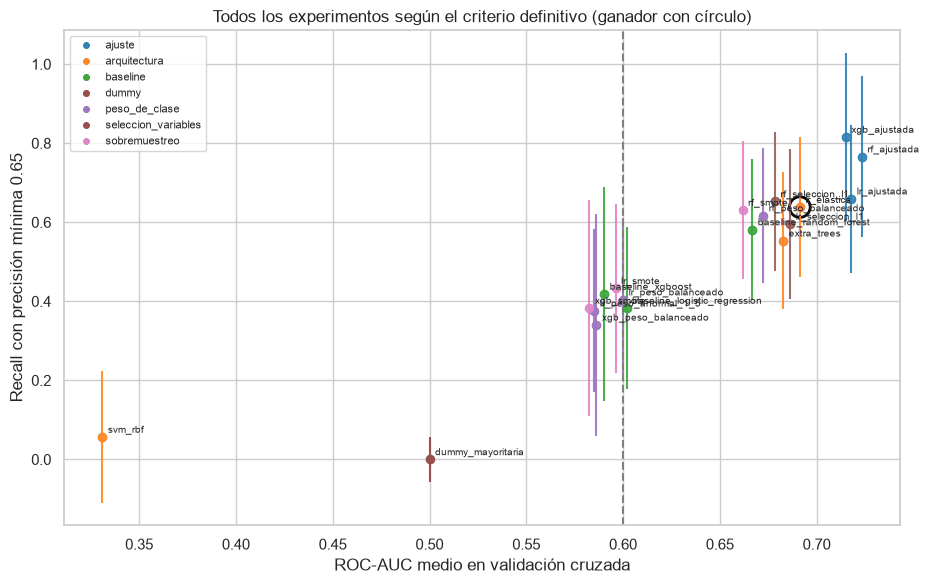

In [18]:
def pick(pool, metric, se_metric):
    best = pool[metric].idxmax()
    limit = pool.loc[best, metric] - pool.loc[best, se_metric]
    equivalent = pool[pool[metric] >= limit]
    chosen = equivalent.sort_values(
        ["complejidad", "cv_roc_auc_mean"], ascending=[True, False]
    ).index[0]
    return best, limit, equivalent, chosen


# Regla inicial: Recall con umbral 0.5 y guardrails débiles.
pool_initial = table[table["candidato_regla_inicial"]]
_, _, equivalent_initial, winner_initial = pick(
    pool_initial, "cv_recall_mean", "error_estandar_recall"
)
row = table.loc[winner_initial]
print("REGLA INICIAL (Recall con umbral 0.5)")
print("Modelos equivalentes:", ", ".join(equivalent_initial.index))
print(f"Elegido: {winner_initial}")
print(
    f"  Recall {row['cv_recall_mean']:.3f}, pero especificidad "
    f"{row['cv_specificity']:.2f} y rango intercuartil de probabilidades "
    f"{row['prob_iqr']:.3f}"
)

# Segunda versión: precisión mínima, sin guardrail de dispersión.
key = f"recall_p{round(PRECISION_FLOOR * 100)}"
pool_floor = table[table["candidato_precision_minima"]]
_, _, equivalent_floor, winner_floor = pick(pool_floor, key, f"{key}_se")
row = table.loc[winner_floor]
print(f"\nREGLA CON PRECISIÓN MÍNIMA {PRECISION_FLOOR}, SIN GUARDRAIL DE DISPERSIÓN")
print("Modelos equivalentes:", ", ".join(equivalent_floor.index))
print(
    f"Elegido: {winner_floor}, con rango intercuartil de probabilidades "
    f"{row['prob_iqr']:.3f}"
)

# Regla definitiva: precisión mínima y dispersión de probabilidades.
pool = table[table["candidato_regla_definitiva"]]
best_name, limit, equivalent, winner = pick(pool, key, f"{key}_se")
print(f"\nREGLA DEFINITIVA (precisión mínima {PRECISION_FLOOR} y dispersión)")
print(
    f"Candidatos con ROC-AUC de al menos {GUARD_AUC} y rango intercuartil de al "
    f"menos {MIN_PROB_IQR}: {len(pool)}"
)
print(f"Mayor Recall con esa precisión: {best_name} ({pool.loc[best_name, key]:.3f})")
print(f"Umbral de equivalencia (un error estándar): {limit:.3f}")
print("Modelos equivalentes:", ", ".join(equivalent.index))
print(f"Elegido, el más simple entre los equivalentes: {winner}")

robust = {}
for floor in PRECISION_FLOORS:
    k = f"recall_p{round(floor * 100)}"
    robust[f"precisión mínima {floor}"] = pick(pool, k, f"{k}_se")[3]
print("\nGanador según la precisión mínima exigida:", robust)

families = sorted(table["family"].unique())
palette = dict(zip(families, sns.color_palette("tab10", len(families)), strict=True))
fig, ax = plt.subplots(figsize=(9.5, 6))
for name, row in table.iterrows():
    ax.errorbar(
        row["cv_roc_auc_mean"],
        row[key],
        yerr=row[f"{key}_se"],
        fmt="o",
        color=palette[row["family"]],
        alpha=0.85,
    )
    ax.annotate(
        name,
        (row["cv_roc_auc_mean"], row[key]),
        fontsize=7,
        xytext=(4, 3),
        textcoords="offset points",
    )
win = table.loc[winner]
ax.scatter(
    win["cv_roc_auc_mean"],
    win[key],
    s=220,
    facecolors="none",
    edgecolors="black",
    linewidths=2,
)
ax.axvline(GUARD_AUC, linestyle="--", color="gray")
handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=palette[f], label=f)
    for f in families
]
ax.legend(handles=handles, fontsize=8, loc="upper left")
ax.set_xlabel("ROC-AUC medio en validación cruzada")
ax.set_ylabel(f"Recall con precisión mínima {PRECISION_FLOOR}")
ax.set_title(
    "Todos los experimentos según el criterio definitivo (ganador con círculo)"
)
plt.tight_layout()
plt.show()

### Comparación con la semana 6

Los baselines se volvieron a entrenar con el mismo split 71/18 y la misma semilla, así que sus métricas de holdout deberían coincidir con las que ya estaban registradas en MLflow en el ticket 10. Es una comprobación de que el protocolo actual reproduce el trabajo anterior.

In [19]:
try:
    reference = mlflow.search_runs(experiment_names=[REFERENCE_EXPERIMENT])
except Exception as exc:
    reference = pd.DataFrame()
    print("No se pudo leer el experimento de la semana 6:", exc)

if reference.empty:
    print("No hay runs de la semana 6 en este servidor.")
else:
    reference = (
        reference.sort_values("start_time")
        .drop_duplicates("tags.mlflow.runName", keep="last")
        .set_index("tags.mlflow.runName")
    )
    mapping = {
        "logistic_regression": "baseline_logistic_regression",
        "random_forest": "baseline_random_forest",
        "xgboost": "baseline_xgboost",
    }
    rows = {}
    for short, full_name in mapping.items():
        old = reference.loc[short] if short in reference.index else None
        rows[short] = {
            "recall_semana6": None if old is None else old["metrics.test_recall"],
            "recall_ahora": RESULTS[full_name]["holdout_recall"],
            "roc_auc_semana6": None if old is None else old["metrics.test_roc_auc"],
            "roc_auc_ahora": RESULTS[full_name]["holdout_roc_auc"],
            "f1_semana6": None if old is None else old["metrics.test_f1"],
            "f1_ahora": RESULTS[full_name]["holdout_f1"],
        }
    display(pd.DataFrame(rows).T.astype(float).round(3))

,recall_semana6,recall_ahora,roc_auc_semana6,roc_auc_ahora,f1_semana6,f1_ahora
logistic_regression,0.7,0.7,0.587,0.587,0.667,0.667
random_forest,0.4,0.4,0.456,0.456,0.444,0.444
xgboost,0.6,0.6,0.625,0.625,0.632,0.632


### Lectura de la selección

* **Tres versiones de la regla, dos resultados.** La regla inicial y la de precisión mínima sin guardrail de dispersión eligen la regresión logística con `C=0.003` (`lr_ajustada`). Su ranking es bueno (ROC-AUC 0.718), pero sus probabilidades apenas varían (rango intercuartil de 0.024), así que su Recall de 0.877 con umbral de 0.5 viene de predecir "anormal" para casi todos (especificidad de 0.17). La regla definitiva elige `lr_elastica`, una regresión logística con penalización elástica.
* **El resultado es estadísticamente un empate.** El error estándar del Recall con precisión mínima está entre 0.17 y 0.20, del mismo orden que la diferencia entre los siete candidatos equivalentes (de 0.58 a 0.77). Con 89 filas no se puede afirmar que un modelo sea mejor que otro. La elección se apoya en parsimonia e interpretabilidad y no en una superioridad demostrada.
* **La elección es robusta a la precisión mínima**, porque con 0.60, 0.65 y 0.70 gana el mismo modelo. Pero depende del guardrail de dispersión: si se exigiera un rango intercuartil de al menos 0.20 en lugar de 0.10, `lr_elastica` (0.152) quedaría fuera y la regla elegiría el Random Forest ajustado (`rf_ajustada`, con Recall de 0.77 con precisión mínima y ROC-AUC de 0.72). Ambos son candidatos razonables y la decisión final es del equipo.
* **Los guardrails hicieron su trabajo.** Sin ellos habrían ganado por Recall el SVM (0.93, con un ROC-AUC peor que el azar) o modelos con probabilidades casi constantes, que ordenan a los pacientes pero no los separan en la escala que ve el usuario.

## 5. Modelo definitivo

El ganador se reentrena con las 89 filas, ya sin separar test, porque con tan pocos datos cada fila cuenta y el modelo saldrá a producción. Si el ganador incluye búsqueda de hiperparámetros, se repite esa misma búsqueda sobre todas las filas y se conserva el mejor pipeline. Las métricas que se reportan son las de la validación cruzada de la sección 4, que estiman qué se puede esperar de este procedimiento. Sobre el modelo reentrenado no queda ningún dato para evaluarlo.

El artefacto se guarda como un único `.joblib` en la raíz del run de MLflow, que es lo que espera la API para cargarlo.

In [20]:
final_estimator = clone(RESULTS[winner]["estimator"])
if isinstance(final_estimator, GridSearchCV | RandomizedSearchCV):
    final_estimator.set_params(n_jobs=-1)
final_estimator.fit(X, y)
final_model = getattr(final_estimator, "best_estimator_", final_estimator)
print("Modelo definitivo:", winner)
print("Hiperparámetros elegidos con todas las filas:")
print(getattr(final_estimator, "best_params_", "sin búsqueda"))

selected = RESULTS[winner]
target = y.to_numpy()
thresholds = np.array(
    [
        threshold_at_precision(target, selected["oof"][r], PRECISION_FLOOR)
        for r in range(N_REPEATS)
    ]
)
valid_thresholds = thresholds[~np.isnan(thresholds)]
suggested_threshold = (
    float(valid_thresholds.mean()) if len(valid_thresholds) else float("nan")
)
cm_operating = sum(
    confusion_matrix(target, (selected["oof"][r] >= t).astype(int), labels=[0, 1])
    for r, t in enumerate(thresholds)
    if not np.isnan(t)
) / max(len(valid_thresholds), 1)

probabilities = final_model.predict_proba(X)[:, 1]
percentiles = pd.DataFrame(
    {
        "percentil": np.arange(101),
        "probabilidad": np.percentile(probabilities, np.arange(101)),
    }
)

MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)
FINAL_PATH = MODELS_DIR / "modelo_final.joblib"
joblib.dump(final_model, FINAL_PATH)
PERCENTILES_PATH = MODELS_DIR / "percentiles_probabilidad.csv"
percentiles.round(5).to_csv(PERCENTILES_PATH, index=False)

matrices = [
    (selected["cm"], "matriz_confusion_umbral_05.png", "umbral 0.5"),
    (
        cm_operating,
        "matriz_confusion_punto_operacion.png",
        f"precisión mínima {PRECISION_FLOOR}",
    ),
]
with mlflow.start_run(run_name="modelo_final") as final_run:
    mlflow.set_tags(
        {
            "family": "final",
            "ganador": winner,
            "entrenado_con": "89 filas, dataset completo",
        }
    )
    mlflow.log_params(simple_params(final_model))
    mlflow.log_params(
        {
            "ganador": winner,
            "criterio": (
                f"recall con precision minima {PRECISION_FLOOR}, "
                f"guardrail roc_auc {GUARD_AUC}"
            ),
            "umbral_sugerido": round(suggested_threshold, 4),
        }
    )
    mlflow.log_metrics(
        {f"seleccion_{k}": selected[k] for k in [*METRIC_COLS, *OPERATING_COLS]}
    )
    mlflow.log_artifact(str(FINAL_PATH))
    mlflow.log_artifact(str(PERCENTILES_PATH))
    for matrix, file_name, title in matrices:
        fig = confusion_figure(matrix, f"{winner}, {title}")
        mlflow.log_figure(fig, file_name)
        plt.close(fig)
FINAL_RUN_ID = final_run.info.run_id
print("Run del modelo definitivo:", FINAL_RUN_ID)
print("Umbral sugerido para la API:", round(suggested_threshold, 3))

Modelo definitivo: lr_elastica
Hiperparámetros elegidos con todas las filas:
{'model__C': 0.01, 'model__l1_ratio': 0.05}


🏃 View run modelo_final at: http://44.215.228.113:5000/#/experiments/4/runs/b234c520c8264c999e98fbf545bc226a
🧪 View experiment at: http://44.215.228.113:5000/#/experiments/4
Run del modelo definitivo: b234c520c8264c999e98fbf545bc226a
Umbral sugerido para la API: 0.502


In [21]:
reloaded = joblib.load(FINAL_PATH)
files = [a.path for a in MlflowClient().list_artifacts(FINAL_RUN_ID)]
joblib_files = [f for f in files if f.endswith(".joblib")]
sample = reloaded.predict_proba(X.head(3))[:, 1]
print("Artefactos del run:", files)
print("Un solo .joblib en la raíz, como exige la API:", len(joblib_files) == 1)
print("Columnas que espera el modelo:", len(reloaded.feature_names_in_))
print(
    "Mismo orden de columnas que el dataset:",
    list(reloaded.feature_names_in_) == list(X.columns),
)
print("predict_proba sobre 3 filas de ejemplo:", sample.round(3))

Artefactos del run: ['matriz_confusion_punto_operacion.png', 'matriz_confusion_umbral_05.png', 'modelo_final.joblib', 'percentiles_probabilidad.csv']
Un solo .joblib en la raíz, como exige la API: True
Columnas que espera el modelo: 37
Mismo orden de columnas que el dataset: True
predict_proba sobre 3 filas de ejemplo: [0.659 0.505 0.604]


,"validación cruzada, media",desviación entre folds,split 71/18 de la semana 6
Recall (umbral 0.5),0.623,0.205,0.500
Precisión (umbral 0.5),0.657,0.168,0.500
F1 (umbral 0.5),0.619,0.144,0.500
ROC-AUC,0.691,0.125,0.562


,valor
Recall con precisión mínima 0.65,0.638
Error estándar de ese Recall,0.177
Precisión promedio (área bajo la curva precisión y Recall),0.720
Umbral sugerido,0.502
Rango intercuartil de las probabilidades,0.152


Probabilidad estimada del modelo definitivo sobre la cohorte, por percentil:
percentil       0      10    25     50     75     90     100
probabilidad  0.458  0.477  0.49  0.507  0.549  0.617  0.749
Matriz con umbral 0.5, sobre los 89 pacientes: verdaderos positivos 29.3, falsos negativos 17.7, falsos positivos 17.0, verdaderos negativos 25.0
Matriz con precisión mínima 0.65, sobre los 89 pacientes: verdaderos positivos 30.0, falsos negativos 17.0, falsos positivos 15.7, verdaderos negativos 26.3


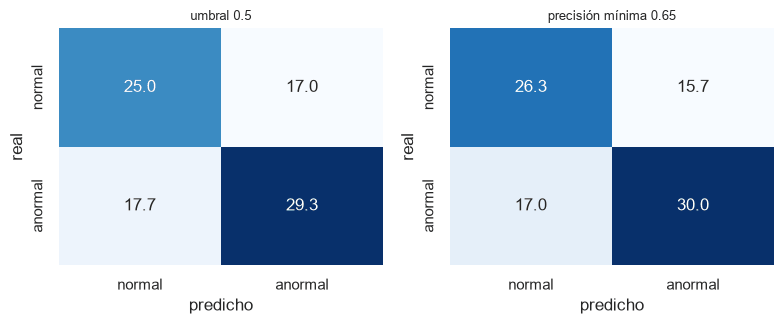

In [22]:
key = f"recall_p{round(PRECISION_FLOOR * 100)}"
final_metrics = pd.DataFrame(
    {
        "validación cruzada, media": [selected[f"cv_{m}_mean"] for m in METRICS],
        "desviación entre folds": [selected[f"cv_{m}_std"] for m in METRICS],
        "split 71/18 de la semana 6": [selected[f"holdout_{m}"] for m in METRICS],
    },
    index=[
        "Recall (umbral 0.5)",
        "Precisión (umbral 0.5)",
        "F1 (umbral 0.5)",
        "ROC-AUC",
    ],
).round(3)
display(final_metrics)

operating = pd.Series(
    {
        f"Recall con precisión mínima {PRECISION_FLOOR}": selected[key],
        "Error estándar de ese Recall": selected[f"{key}_se"],
        "Precisión promedio (área bajo la curva precisión y Recall)": selected[
            "avg_precision"
        ],
        "Umbral sugerido": suggested_threshold,
        "Rango intercuartil de las probabilidades": selected["prob_iqr"],
    }
)
display(operating.round(3).to_frame("valor"))

quantile_points = [0, 10, 25, 50, 75, 90, 100]
print("Probabilidad estimada del modelo definitivo sobre la cohorte, por percentil:")
print(percentiles.set_index("percentil").loc[quantile_points].T.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(8, 3.4))
for ax, (matrix, _, title) in zip(axes, matrices, strict=True):
    tn, fp, fn, tp = matrix.ravel()
    print(
        f"Matriz con {title}, sobre los 89 pacientes: verdaderos positivos {tp:.1f}, "
        f"falsos negativos {fn:.1f}, falsos positivos {fp:.1f}, "
        f"verdaderos negativos {tn:.1f}"
    )
    labels = ["normal", "anormal"]
    sns.heatmap(
        matrix,
        annot=True,
        fmt=".1f",
        cmap="Blues",
        cbar=False,
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
    )
    ax.set_xlabel("predicho")
    ax.set_ylabel("real")
    ax.set_title(title, fontsize=9)
plt.tight_layout()
plt.show()

### Lectura del modelo definitivo

* **Desempeño esperable, modesto.** Con validación cruzada repetida el modelo logra ROC-AUC de 0.69, Recall de 0.62 y precisión de 0.66 con umbral de 0.5, y Recall de 0.64 cuando se exige una precisión de 0.65. Supera al clasificador trivial en precisión y en ROC-AUC, pero su F1 (0.62) queda por debajo del F1 del trivial (0.69). Con clases casi balanceadas, F1 premia predecir siempre "anormal", por eso no sirve como criterio único.
* **La incertidumbre es grande.** La desviación entre folds va de 0.13 a 0.21 en todas las métricas. Las cifras del split 71/18 de la semana 6 (Recall 0.50, ROC-AUC 0.56) caen dentro de esa dispersión y no deben leerse por separado.
* **Las probabilidades quedan cerca de la prevalencia.** Sobre la cohorte van de 0.46 a 0.75, con mediana de 0.51. Es lo esperable con señal débil, y significa que un puntaje de 0 a 100 basado directamente en la probabilidad se concentrará entre 46 y 75. Para la API conviene usar el percentil de la probabilidad dentro de la cohorte (el archivo `percentiles_probabilidad.csv` queda registrado en el run de MLflow) y un umbral cercano a 0.50, que es el sugerido para una precisión mínima de 0.65.
* **Matriz de confusión con precisión mínima de 0.65**, sobre los 89 pacientes: 30 verdaderos positivos, 17 falsos negativos, 15.7 falsos positivos y 26.3 verdaderos negativos.

## 6. Interpretabilidad: odds ratios de la regresión logística

La regresión logística se defendió por ser interpretable, así que aquí se reporta lo que dice. Un odds ratio mayor que 1 indica que la variable se asocia con más riesgo de alteración del neurodesarrollo y menor que 1 con menos riesgo.

Cómo leerlos:

* Las variables continuas se escalan con `RobustScaler`, por lo que su odds ratio es **por cada IQR** de aumento (la columna `iqr` da ese rango en unidades originales). En las binarias es el cambio de 0 a 1.
* Los intervalos son percentiles de 500 remuestreos bootstrap. Con 89 filas y 36 variables serán anchos, y eso es información: indica cuánta incertidumbre real hay.
* La búsqueda de hiperparámetros pidió una regularización muy fuerte para la regresión logística, lo que encoge sus coeficientes hacia 1. Por eso los odds ratios y sus intervalos se calculan con regularización estándar (`C=1`), que es más legible, y se marca con una cruz roja el valor de la regresión logística ajustada para ver cuánto se encoge cada efecto.
* El modelo definitivo (`lr_elastica`) es también una regresión logística, pero con una regularización tan fuerte que sus coeficientes quedan casi en 1. Por eso los odds ratios se reportan con regularización estándar, que es más legible. Son una lectura de las asociaciones en los datos y no los coeficientes exactos del modelo desplegado.
* Son asociaciones, no efectos causales. Además, cuando dos variables están muy correlacionadas (por ejemplo `BirthWeight` y `RoundHeadAtBirth`), el modelo reparte el efecto entre ellas.

In [23]:
C_TUNED = RESULTS["lr_ajustada"]["best_params"].get("model__C", 1.0)
C_STANDARD = 1.0


def odds_table(c, n_boot=500):
    base = make_pipeline(
        LogisticRegression(C=c, max_iter=2000, random_state=RANDOM_STATE)
    )
    fitted_all = clone(base).fit(X, y)
    names = [
        n.split("__", 1)[1]
        for n in fitted_all.named_steps["preprocess"].get_feature_names_out()
    ]
    point = np.exp(fitted_all.named_steps["model"].coef_[0])
    rng = np.random.default_rng(RANDOM_STATE)
    boot = []
    for _ in range(n_boot):
        idx = rng.choice(len(X), size=len(X), replace=True)
        if y.iloc[idx].nunique() < 2:
            continue
        fitted = clone(base).fit(X.iloc[idx], y.iloc[idx])
        boot.append(np.exp(fitted.named_steps["model"].coef_[0]))
    low, high = np.percentile(boot, [2.5, 97.5], axis=0)
    table_ = pd.DataFrame(
        {"odds_ratio": point, "ic95_bajo": low, "ic95_alto": high}, index=names
    )
    return table_.drop(index=constant, errors="ignore")


odds_standard = odds_table(C_STANDARD)
odds_tuned = odds_table(C_TUNED)

odds = odds_standard.copy()
odds["odds_ratio_lr_ajustada"] = odds_tuned["odds_ratio"]
iqr = X[CONTINUOUS_VARS].quantile(0.75) - X[CONTINUOUS_VARS].quantile(0.25)
odds["unidad"] = np.where(odds.index.isin(CONTINUOUS_VARS), "por IQR", "de 0 a 1")
odds["iqr"] = iqr.reindex(odds.index)
odds["ic_excluye_1"] = (odds["ic95_bajo"] > 1) | (odds["ic95_alto"] < 1)
odds["fuerza"] = np.abs(np.log(odds["odds_ratio"]))
top_or = odds.sort_values("fuerza", ascending=False).head(15)
print(f"Columnas ic95 y odds_ratio: regularización estándar, C={C_STANDARD}")
print(f"Columna odds_ratio_lr_ajustada: C={C_TUNED}, coeficientes encogidos")
top_or.drop(columns="fuerza").round(2)

Columnas ic95 y odds_ratio: regularización estándar, C=1.0
Columna odds_ratio_lr_ajustada: C=0.003, coeficientes encogidos


,odds_ratio,ic95_bajo,ic95_alto,odds_ratio_lr_ajustada,unidad,iqr,ic_excluye_1
PROM,0.41,0.24,1.00,1.00,de 0 a 1,NaN,True
SepsisnegativeCulture,2.13,0.90,4.75,1.01,de 0 a 1,NaN,False
sepsis,2.10,1.01,3.28,1.01,de 0 a 1,NaN,True
type.of.ressucitation_advanced,0.52,0.33,1.01,1.00,de 0 a 1,NaN,False
preeclampsia,0.53,0.25,1.46,1.01,de 0 a 1,NaN,False
IUGR,1.70,0.76,4.11,1.02,de 0 a 1,NaN,False
hypothyroid,0.59,0.28,1.64,0.99,de 0 a 1,NaN,False
BirthWeight,0.59,0.25,1.38,0.96,por IQR,580.0,False
B.C,1.63,0.66,3.54,1.01,de 0 a 1,NaN,False
BPD,1.60,0.86,2.67,1.01,de 0 a 1,NaN,False


🏃 View run modelo_final at: http://44.215.228.113:5000/#/experiments/4/runs/b234c520c8264c999e98fbf545bc226a
🧪 View experiment at: http://44.215.228.113:5000/#/experiments/4


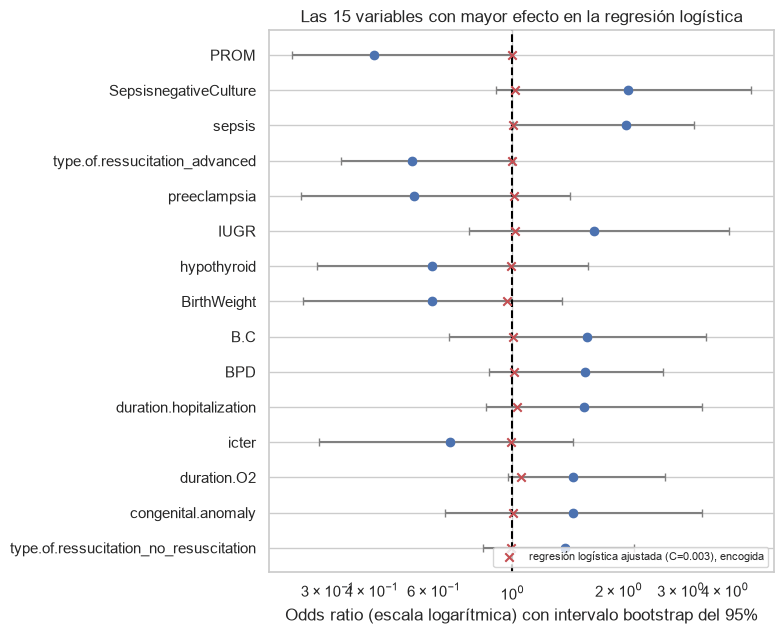

Variables cuyo intervalo no incluye 1: ['PROM', 'pneumothorax', 'sepsis']


In [24]:
plot = top_or.iloc[::-1]
ypos = np.arange(len(plot))
fig, ax = plt.subplots(figsize=(8, 6.5))
ax.errorbar(
    plot["odds_ratio"],
    ypos,
    xerr=[
        np.clip(plot["odds_ratio"] - plot["ic95_bajo"], 0, None),
        np.clip(plot["ic95_alto"] - plot["odds_ratio"], 0, None),
    ],
    fmt="o",
    color="#4C72B0",
    ecolor="gray",
    capsize=3,
)
ax.scatter(
    plot["odds_ratio_lr_ajustada"],
    ypos,
    marker="x",
    color="#C44E52",
    zorder=3,
    label=f"regresión logística ajustada (C={C_TUNED}), encogida",
)
ax.axvline(1, linestyle="--", color="black")
ax.legend(loc="lower right", fontsize=8)
ax.set_xscale("log")
ax.set_yticks(ypos)
ax.set_yticklabels(plot.index)
ax.set_xlabel("Odds ratio (escala logarítmica) con intervalo bootstrap del 95%")
ax.set_title("Las 15 variables con mayor efecto en la regresión logística")
plt.tight_layout()
odds_path = MODELS_DIR / "odds_ratios.csv"
odds.round(4).to_csv(odds_path)
with mlflow.start_run(run_id=FINAL_RUN_ID):
    mlflow.log_artifact(str(odds_path))
    mlflow.log_figure(fig, "odds_ratios.png")
plt.show()
print("Variables cuyo intervalo no incluye 1:", list(odds.index[odds["ic_excluye_1"]]))

### Lectura de los odds ratios

* **Ninguna asociación es firme.** De 36 variables, solo 3 tienen un intervalo bootstrap del 95% que no incluye 1 (`sepsis`, `PROM` y `pneumothorax`), y con 36 comparaciones se esperarían una o dos solo por azar. Además, los intervalos de `PROM` (0.24 a 1.00) y de `pneumothorax` (1.00 a 1.49) apenas rozan el 1. En variables con pocos casos positivos, muchos remuestreos no las incluyen y su coeficiente queda en 0, lo que ancla un extremo del intervalo en 1, así que no deben leerse como efectos firmes.
* **`sepsis` es la asociación más llamativa.** Odds ratio de 2.10 (intervalo de 1.01 a 3.28) con solo 5 casos positivos, lo que la hace frágil. Tiene sentido clínico, pero con este tamaño de muestra es una hipótesis y no un hallazgo.
* **Las variables continuas más asociadas van en la dirección esperada, con intervalos anchos.** `BirthWeight` 0.59 por cada 580 g (0.25 a 1.38), `duration.hopitalization` 1.59 por cada 21 días (0.84 a 3.46) y `duration.O2` 1.49 por cada 7 días (0.97 a 2.71). Sus intervalos incluyen 1 en parte porque estas variables están correlacionadas entre sí (el peso al nacer con los días de hospitalización, con rho de menos 0.65) y el modelo reparte el efecto entre ellas.
* **La regularización fuerte aplasta los efectos.** En la regresión logística ajustada (`C=0.003`) los odds ratios de las variables principales quedan entre 0.96 y 1.05. Con señal débil y pocos datos, la validación prefiere modelos que casi no se apartan de la prevalencia.

## 7. La calculadora y sus valores por defecto

El formulario actual pide solo 5 variables y completa las demás con la moda (binarias) o la mediana (continuas) de la cohorte, tal como hace `compute_defaults.py`. Entre esas variables completadas están `duration.hopitalization` y `duration.O2`, dos de las más asociadas con el target según la sección 1. Aquí se mide qué tanto del puntaje viene del paciente y qué tanto de los valores por defecto.

Tres análisis:

1. **Barrido de sensibilidad:** con un paciente típico, cuánto se mueve la probabilidad al variar cada variable dentro de su rango habitual (percentil 5 a 95).
2. **Dispersión:** cuánto varía la probabilidad cuando solo cambian las 5 variables del formulario, frente a cuando solo cambian las dos duraciones.
3. **Diseño del formulario:** desempeño en validación cruzada (ROC-AUC, Recall con precisión mínima y precisión promedio) de una calculadora que pide solo ciertas variables y completa el resto con defaults, comparando el formulario actual con formularios basados en el ranking de la sección 1.

Probabilidad del paciente típico con defaults de cohorte: 0.503


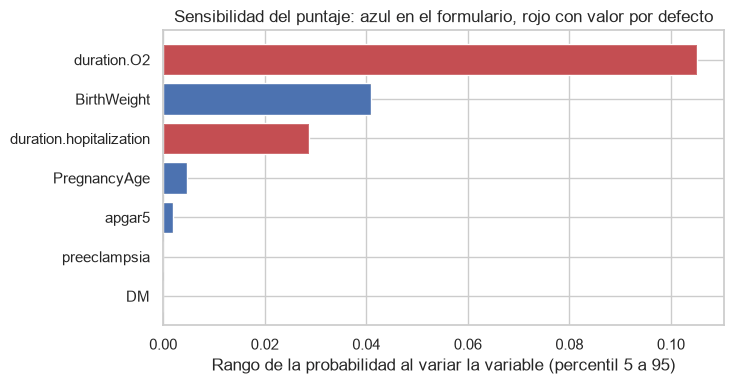

,en_formulario,prob_min,prob_max,rango
variable,,,,
duration.O2,False,0.499,0.604,0.105
BirthWeight,True,0.482,0.523,0.041
duration.hopitalization,False,0.496,0.524,0.029
PregnancyAge,True,0.502,0.506,0.005
apgar5,True,0.503,0.505,0.002
preeclampsia,True,0.503,0.503,0.000
DM,True,0.503,0.503,0.000


In [25]:
def cohort_defaults(frame, free_fields):
    values = {}
    for col in frame.columns:
        if col in free_fields:
            continue
        unique = set(frame[col].dropna().unique())
        if unique <= {0, 1}:
            values[col] = int(frame[col].mode(dropna=True).iloc[0])
        else:
            values[col] = float(frame[col].median())
    return values


defaults = cohort_defaults(X, FORM_FIELDS)
typical_form = {
    f: (0 if f in binary_cols else float(X[f].median())) for f in FORM_FIELDS
}
typical = pd.DataFrame([{**defaults, **typical_form}])[X.columns]
p_typical = float(final_model.predict_proba(typical)[0, 1])
print(f"Probabilidad del paciente típico con defaults de cohorte: {p_typical:.3f}")


def sweep(column, values):
    frame = pd.concat([typical] * len(values), ignore_index=True)
    frame[column] = values
    return final_model.predict_proba(frame)[:, 1]


rows = []
for col in [*FORM_FIELDS, "duration.hopitalization", "duration.O2"]:
    if col in binary_cols:
        values = np.array([0, 1])
    else:
        values = np.linspace(X[col].quantile(0.05), X[col].quantile(0.95), 30)
    probs = sweep(col, values)
    rows.append(
        {
            "variable": col,
            "en_formulario": col in FORM_FIELDS,
            "prob_min": probs.min(),
            "prob_max": probs.max(),
            "rango": probs.max() - probs.min(),
        }
    )
sensitivity = pd.DataFrame(rows).set_index("variable")
sensitivity = sensitivity.sort_values("rango", ascending=False)

fig, ax = plt.subplots(figsize=(7.5, 4))
colors = ["#4C72B0" if f else "#C44E52" for f in sensitivity["en_formulario"]]
ax.barh(sensitivity.index[::-1], sensitivity["rango"][::-1], color=colors[::-1])
ax.set_xlabel("Rango de la probabilidad al variar la variable (percentil 5 a 95)")
ax.set_title(
    "Sensibilidad del puntaje: azul en el formulario, rojo con valor por defecto"
)
plt.tight_layout()
plt.show()
sensitivity.round(3)

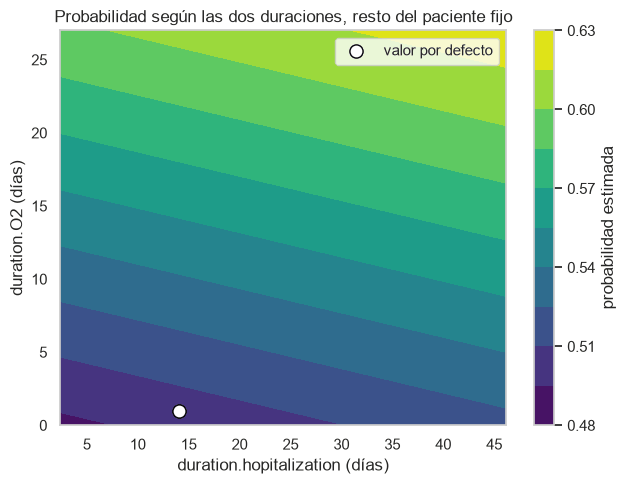

solo cambian las 5 variables del formulario    0.018
solo cambian las 2 duraciones                  0.039
cambian las 37 variables (modelo completo)     0.059
Name: rango intercuartil de la probabilidad, dtype: float64

mínimo     0.458
p10        0.477
p25        0.490
mediana    0.507
p75        0.549
p90        0.617
máximo     0.749
Name: probabilidad estimada en la cohorte, dtype: float64

In [26]:
h_vals = np.linspace(
    X["duration.hopitalization"].quantile(0.05),
    X["duration.hopitalization"].quantile(0.95),
    25,
)
o_vals = np.linspace(
    X["duration.O2"].quantile(0.05), X["duration.O2"].quantile(0.95), 25
)
grid_h, grid_o = np.meshgrid(h_vals, o_vals)
frame = pd.concat([typical] * grid_h.size, ignore_index=True)
frame["duration.hopitalization"] = grid_h.ravel()
frame["duration.O2"] = grid_o.ravel()
prob_grid = final_model.predict_proba(frame)[:, 1].reshape(grid_h.shape)

fig, ax = plt.subplots(figsize=(6.5, 5))
contour = ax.contourf(grid_h, grid_o, prob_grid, levels=12, cmap="viridis")
fig.colorbar(contour, label="probabilidad estimada")
ax.scatter(
    [X["duration.hopitalization"].median()],
    [X["duration.O2"].median()],
    color="white",
    edgecolor="black",
    s=90,
    label="valor por defecto",
)
ax.set_xlabel("duration.hopitalization (días)")
ax.set_ylabel("duration.O2 (días)")
ax.set_title("Probabilidad según las dos duraciones, resto del paciente fijo")
ax.legend()
plt.tight_layout()
plt.show()


def iqr_of(values):
    q75, q25 = np.percentile(values, [75, 25])
    return q75 - q25


only_form = X.copy()
for col, value in defaults.items():
    only_form[col] = value
only_durations = pd.concat([typical] * len(X), ignore_index=True)
only_durations["duration.hopitalization"] = X["duration.hopitalization"].to_numpy()
only_durations["duration.O2"] = X["duration.O2"].to_numpy()

spread = pd.Series(
    {
        "solo cambian las 5 variables del formulario": iqr_of(
            final_model.predict_proba(only_form)[:, 1]
        ),
        "solo cambian las 2 duraciones": iqr_of(
            final_model.predict_proba(only_durations)[:, 1]
        ),
        "cambian las 37 variables (modelo completo)": iqr_of(
            final_model.predict_proba(X)[:, 1]
        ),
    },
    name="rango intercuartil de la probabilidad",
)
display(spread.round(3))
cohort_probs = final_model.predict_proba(X)[:, 1]
quantiles = pd.Series(
    np.percentile(cohort_probs, [0, 10, 25, 50, 75, 90, 100]),
    index=["mínimo", "p10", "p25", "mediana", "p75", "p90", "máximo"],
    name="probabilidad estimada en la cohorte",
)
quantiles.round(3)

Top 5 del ranking: ['BirthWeight', 'duration.hopitalization', 'duration.O2', 'SepsisnegativeCulture', 'PregnancyAge']
Top 8 del ranking: ['BirthWeight', 'duration.hopitalization', 'duration.O2', 'SepsisnegativeCulture', 'PregnancyAge', 'IUGR', 'icter', 'BPD']


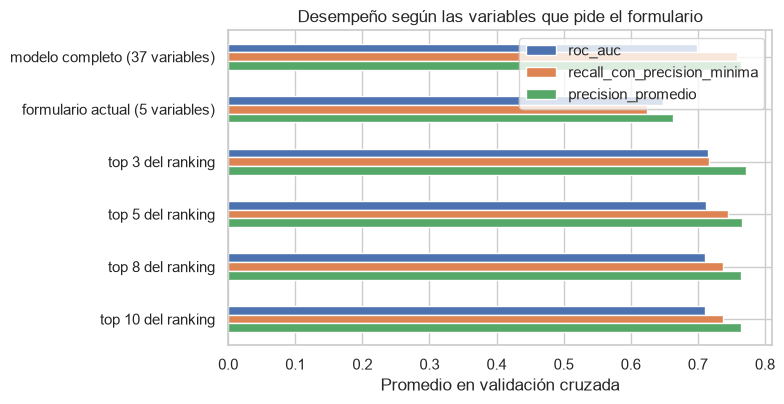

,roc_auc,recall_con_precision_minima,precision_promedio
modelo completo (37 variables),0.698,0.759,0.764
formulario actual (5 variables),0.648,0.624,0.663
top 3 del ranking,0.716,0.716,0.772
top 5 del ranking,0.713,0.745,0.766
top 8 del ranking,0.711,0.738,0.765
top 10 del ranking,0.710,0.738,0.765


In [27]:
frozen = clone(final_model)


def evaluate_form(fields):
    oof_form = np.zeros((N_REPEATS, len(X)))
    for k, (tr, te) in enumerate(OUTER_CV.split(X, y)):
        fitted = clone(frozen).fit(X.iloc[tr], y.iloc[tr])
        frame = X.iloc[te].copy()
        if len(fields) < X.shape[1]:
            for col, value in cohort_defaults(X.iloc[tr], fields).items():
                frame[col] = value
        oof_form[k // N_SPLITS, te] = fitted.predict_proba(frame)[:, 1]
    t = y.to_numpy()
    reps = range(N_REPEATS)
    return pd.Series(
        {
            "roc_auc": np.mean([roc_auc_score(t, oof_form[r]) for r in reps]),
            "recall_con_precision_minima": np.mean(
                [recall_at_precision(t, oof_form[r], PRECISION_FLOOR) for r in reps]
            ),
            "precision_promedio": np.mean(
                [average_precision_score(t, oof_form[r]) for r in reps]
            ),
        }
    )


ordered = list(ranking.index)
designs = {
    "modelo completo (37 variables)": list(X.columns),
    "formulario actual (5 variables)": FORM_FIELDS,
    "top 3 del ranking": ordered[:3],
    "top 5 del ranking": ordered[:5],
    "top 8 del ranking": ordered[:8],
    "top 10 del ranking": ordered[:10],
}
form_results = pd.DataFrame({name: evaluate_form(f) for name, f in designs.items()}).T
print("Top 5 del ranking:", ordered[:5])
print("Top 8 del ranking:", ordered[:8])

fig, ax = plt.subplots(figsize=(8, 4.2))
form_results.plot.barh(ax=ax)
ax.invert_yaxis()
ax.set_xlabel("Promedio en validación cruzada")
ax.set_title("Desempeño según las variables que pide el formulario")
plt.tight_layout()
plt.show()
form_results.round(3)

Nota metodológica: el ranking de la sección 1 se calculó con todas las filas y los hiperparámetros del modelo también se eligieron con todas las filas, así que las comparaciones entre formularios son exploratorias y algo optimistas para los diseños basados en el ranking. Sirven para comparar diseños entre sí, no como estimación final de desempeño.

### Lectura de la calculadora

* **La calculadora casi no depende del formulario.** Con el modelo definitivo, `DM` y `preeclampsia` no mueven el puntaje (rango de 0.000), `apgar5` y `PregnancyAge` lo mueven menos de 0.01 y solo `BirthWeight` tiene un efecto apreciable (0.04). En cambio, `duration.O2` mueve la probabilidad en 0.105 y `duration.hopitalization` en 0.029, y ambas se completan hoy con valores por defecto.
* **Los defaults pesan más que el paciente.** El rango intercuartil de la probabilidad es 0.018 cuando cambian solo las 5 variables del formulario y 0.039 cuando cambian solo las 2 duraciones. Es decir, los dos valores que el usuario no ingresa mueven el puntaje más del doble que los cinco que sí ingresa. Es una limitación importante del prototipo actual.
* **Un formulario mejor es posible sin agregar muchos campos.** Con el formulario actual, el ROC-AUC en validación cruzada es 0.65 y el Recall con precisión mínima 0.62. Pidiendo solo las 3 primeras variables del ranking (`BirthWeight`, `duration.hopitalization` y `duration.O2`) suben a 0.72 y 0.72, y con las 5 primeras a 0.71 y 0.745, comparables al modelo completo (0.70 y 0.76). Como el alcance del proyecto es la predicción al momento del alta, las dos duraciones ya se conocen y pueden ingresarse.
* **Advertencia.** Estas comparaciones son exploratorias, porque el ranking y los hiperparámetros se eligieron con todas las filas, lo que favorece un poco a los diseños basados en el ranking.

## 8. Resumen de entregables

In [28]:
print("Modelo definitivo:", winner)
print("Run en MLflow:", FINAL_RUN_ID)
print("MODEL_URI para la API:", f"runs:/{FINAL_RUN_ID}/modelo_final.joblib")
print("Ranking de variables:", RANKING_PATH.relative_to(ROOT))
print("Servidor donde quedó registrado:", TRACKING_URI)

Modelo definitivo: lr_elastica
Run en MLflow: b234c520c8264c999e98fbf545bc226a
MODEL_URI para la API: runs:/b234c520c8264c999e98fbf545bc226a/modelo_final.joblib
Ranking de variables: docs\ranking_variables.csv
Servidor donde quedó registrado: http://44.215.228.113:5000


### Conclusiones

1. **El modelo definitivo es `lr_elastica`**, una regresión logística con penalización elástica y regularización fuerte, entrenada con las 89 filas. Su desempeño esperado es modesto (ROC-AUC de 0.69) y está estadísticamente empatado con varios modelos alternativos, entre ellos un Random Forest ajustado.
2. **Ninguna mejora probada superó el ruido de la validación.** Ajuste de hiperparámetros, pesos de clase, selección de variables, sobremuestreo y arquitecturas nuevas dieron resultados equivalentes. La mejora más consistente frente a los baselines es el ajuste de regularización (ROC-AUC de 0.60 a 0.72 en la regresión logística), y aun así no es concluyente con este tamaño de muestra. Con 89 filas los datos favorecen modelos simples.
3. **El diagnóstico de la semana 6 debe revisarse.** Con validación cruzada repetida, el Random Forest baseline es el mejor de los tres baselines (ROC-AUC de 0.667) y la regresión logística baseline la más débil en Recall (0.52). El split de 18 filas invertía ese orden.
4. **Recomendaciones para la API y el dashboard.** Usar el percentil de la probabilidad en lugar de la probabilidad directa, pedir en el formulario `BirthWeight`, `duration.hopitalization` y `duration.O2`, y documentar en el reporte que el puntaje actual está dominado por los valores por defecto.

**Decisiones abiertas del equipo:** la precisión mínima de 0.65, el guardrail de dispersión de 0.10 y, según cómo se fijen, la elección entre `lr_elastica` y `rf_ajustada`. Al volver a ejecutar este notebook con `MLFLOW_TRACKING_URI` apuntando al servidor compartido, los experimentos y el modelo definitivo quedan registrados ahí, y `MODEL_URI` debe actualizarse con el nuevo `run_id`.